In [1]:
import os
from pathlib import Path
#import jwst
#print(jwst.__version__)
#from jwst import datamodels
#from jwst.datamodels import dqflags
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
#plt.rcParams['mathtext.default'] = 'regular'
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit, minimize
from scipy.stats import norm, poisson
from scipy.special import gamma
from scipy.interpolate import interp1d
from pathlib import Path
# import natural units:
import natural_units as nu
# multi-core/thread:
import concurrent.futures
import math
import matplotlib.ticker as ticker

# convert charge to sigma:
def sigma_from_charge(charge, mdm):
    return 16 * np.pi * nu.aEM**2 * charge**2 * nu.Reduced_Mass(mdm, nu.mElectron)**2 / (nu.aEM * nu.mElectron)**4 / nu.cm**2

def charge_sigma_conversion(arr):
    dim = len(arr)
    limit = np.zeros((dim,2))
    limit[:,0] = arr[:,0]
    for i_terr in range(dim):
        limit[i_terr,1] = sigma_from_charge(arr[i_terr,1], arr[i_terr,0])
    return limit

where do all the bounds come from?? \
SLAC: https://arxiv.org/abs/hep-ex/9804008 \
LSND and MiniBooNE: https://arxiv.org/abs/1806.03310 \
ArgoNeuT: https://arxiv.org/abs/1911.07996 \
SENSEI: https://arxiv.org/abs/2305.04964 \
BEBC: https://arxiv.org/abs/2011.08153 \
milliQan: https://arxiv.org/abs/2005.06518 \
LEP: https://iopscience.iop.org/article/10.1088/1126-6708/2000/05/003 \
LHC: https://arxiv.org/abs/1410.6816  \
XENON1T cosmic: https://arxiv.org/abs/2010.11190 \
Super-K cosmic: https://arxiv.org/abs/2002.11732 \
\
all others: \
molecular cloud: https://arxiv.org/abs/2211.05787 \



In [2]:
dn_min = -200
dn_max = 400
dn_range = range(dn_min, dn_max)
log_m_min  = -3
log_m_max  = 1
n_m    = 33   # From 1e-3  to 10 GeV
m_grid      = np.logspace(log_m_min, log_m_max, n_m)
#log cs shift from the balloon line
center_line = np.array([2.15504637e-23, 1.88334907e-23, 1.53030461e-23, 1.32738030e-23,
       1.26359147e-23, 1.37889395e-23, 1.61669130e-23, 1.95514385e-23,
       2.40008514e-23, 3.14137096e-23, 4.03532201e-23, 5.19960700e-23,
       6.95747264e-23, 9.69011074e-23, 1.40957345e-22, 2.05768490e-22,
       2.84518575e-22, 3.82210762e-22, 5.17381239e-22, 7.29305911e-22,
       1.08351297e-21, 1.55439713e-21, 2.15203017e-21, 3.00211451e-21,
       4.12016417e-21, 5.67974728e-21, 7.78952222e-21, 1.06757849e-20,
       1.45615810e-20, 1.99263396e-20, 2.70914228e-20, 3.67600191e-20,
       4.94000000e-20])
log_cs_min = -3
log_cs_max = 0
n_cs   = 49
cs_grid = np.logspace(log_cs_min, log_cs_max, n_cs)

# signal_gird = np.loadtxt('../SHIELDING_RESULT/signal_total_grid.txt')[:25]

jwst_result_path = Path('../mask/results/masked')
# 使用 iterdir() 遍历目录中的文件，并只选择 .txt 文件
jwst_pvd = [file for file in jwst_result_path.iterdir() if file.suffix == ".txt" and file.stem != "output" and '00001_nrs2' in file.stem]

other_curves_path = Path('./other_curves')
CMB_Neff = np.loadtxt(other_curves_path / 'CMB_Neff.txt')
BBN_Neff = np.loadtxt(other_curves_path / 'BBN_Neff.txt')
XQC = np.loadtxt(other_curves_path / 'XQC_4e-3.txt')
CMB = np.loadtxt(other_curves_path / 'CMB.txt')
CMB_Neff_2 = np.loadtxt(other_curves_path / 'CMB_Neff_2.txt')
BBN_Neff_2 = np.loadtxt(other_curves_path / 'BBN_Neff_2.txt')
Earth_magnetic_field = np.loadtxt(other_curves_path / 'Earth_magnetic_field.txt')
DD_upper = np.loadtxt(other_curves_path / 'DD_upper.txt')
DD_lower_100_percent = np.loadtxt(other_curves_path / 'DD_lower_100_percent.txt')
DD_x_points = np.sort(np.concatenate((DD_upper[:,0], DD_lower_100_percent[:,0])))
DD_upper_interp = interp1d(DD_upper[:,0], DD_upper[:,1], bounds_error=False, fill_value="extrapolate")
DD_lower_100_interp = interp1d(DD_lower_100_percent[:,0], DD_lower_100_percent[:,1], bounds_error=False, fill_value="extrapolate")
RRS_upper = np.loadtxt(other_curves_path / 'RRS_upper.txt')
RRS_lower = np.loadtxt(other_curves_path / 'RRS_lower.txt')
RRS_x_points = RRS_lower[1:,0]
RRS_upper_interp = interp1d(RRS_upper[:,0], RRS_upper[:,1], bounds_error=False, fill_value="extrapolate")
RRS_lower_interp = interp1d(RRS_lower[:,0], RRS_lower[:,1], bounds_error=False, fill_value="extrapolate")
molecular_cloud_dense_upper = np.loadtxt(other_curves_path / 'molecular_cloud_dense_upper.txt')
molecular_cloud_diffuse = np.loadtxt(other_curves_path / 'molecular_cloud_diffuse.txt')
# accelerator based limits:
SLAC = np.loadtxt(other_curves_path / 'SLAC.txt')
terrestrial_limits = np.loadtxt(other_curves_path / 'terrestrial_limits.txt')
LSND_charge = np.loadtxt(other_curves_path / 'LSND_charge.txt')
LSND = charge_sigma_conversion(LSND_charge)
miniboone_charge = np.loadtxt(other_curves_path / 'miniboone_charge.txt')
miniboone = charge_sigma_conversion(miniboone_charge)
SENSEI_charge = np.loadtxt(other_curves_path / 'SENSEI_charge.txt')
SENSEI = charge_sigma_conversion(SENSEI_charge)
BEBC_charge = np.loadtxt(other_curves_path / 'BEBC_charge.txt')
BEBC = charge_sigma_conversion(BEBC_charge)
milliQan_charge = np.loadtxt(other_curves_path / 'milliQan_charge.txt')
milliQan = charge_sigma_conversion(milliQan_charge)
LEP_charge = np.loadtxt(other_curves_path / 'LEP_charge.txt')
LEP = charge_sigma_conversion(LEP_charge)
ArgoNeuT_charge = np.loadtxt(other_curves_path / 'ArgoNeuT_charge.txt')
ArgoNeuT = charge_sigma_conversion(ArgoNeuT_charge)
# cosmic produced:
Super_K = np.loadtxt(other_curves_path / 'Super-K.txt')
XENON1T_4e_3_charge = np.loadtxt(other_curves_path / 'XENON1T_charge_4e-3.txt')
XENON1T_4e_3 = charge_sigma_conversion(XENON1T_4e_3_charge)
# others:
darkness_upper = np.loadtxt(other_curves_path / 'DarkNESS.txt')
darkness_mod = np.loadtxt(other_curves_path / 'darkness_mod.txt')
darkness_rate = np.loadtxt(other_curves_path / 'darkness_rate.txt')

frac_1_dir_constraints_dir = './advan_constraint/frac_1/constraints/'
best_frac_1_grid = np.zeros((49,33))   # cs from 1e-6 to 1e-3 of center line
for file in Path(frac_1_dir_constraints_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_frac_1_grid += constraint_grid
best_frac_1_grid = (best_frac_1_grid>0)
find_non_zero = np.sum(best_frac_1_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_1_frac_limit = np.zeros((33 - constraint_start, 2))
for col in range(constraint_start, 33):
    indices = np.where(best_frac_1_grid[:, col] == 1)[0]
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_1_frac_limit[index_temp, 0] = m_grid[col]
    best_1_frac_limit[index_temp, 1] = center_line[col] * 1e-3 * cs_grid[lower_index]

/opt/homebrew/Caskroom/miniforge/base/envs/jwst/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


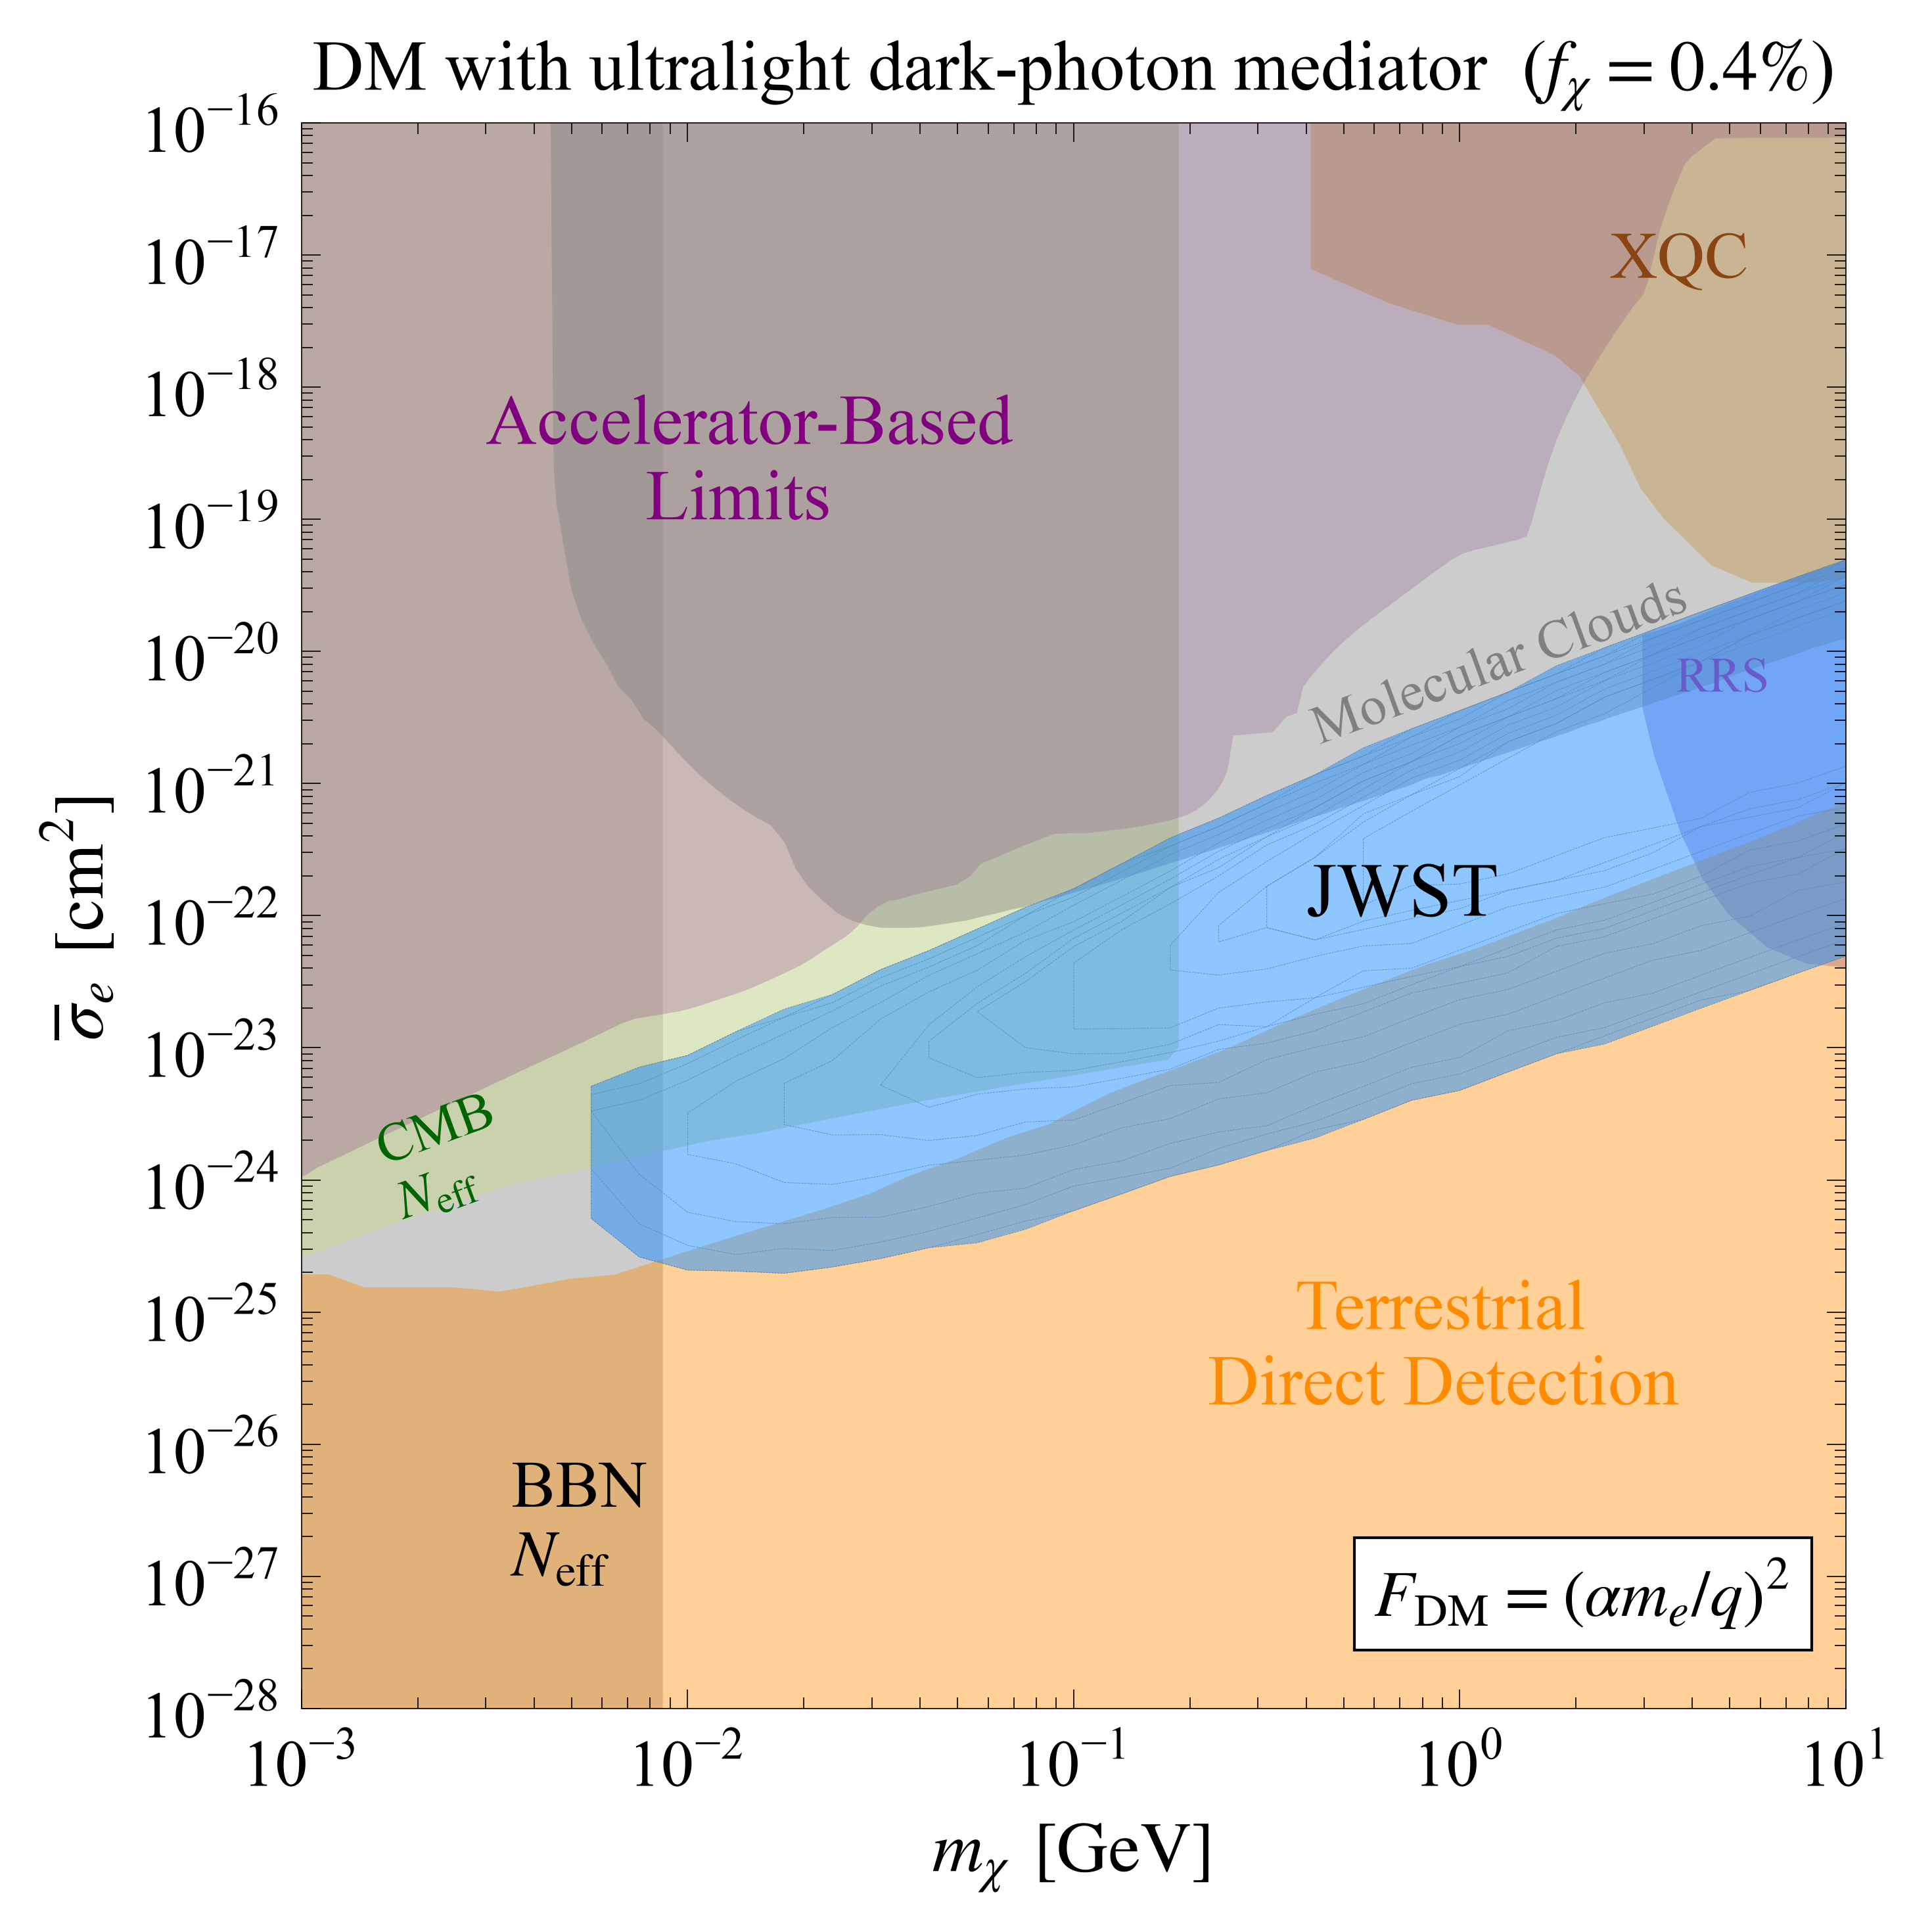

In [3]:
#plot parameters
plt_xmin = 1e-4
plt_xmax = 10
plt_ymin = 1e-40
plt_ymax = 1e-15

frac = '4e-3'
output_dir = './advan_constraint/frac_' + frac + '/'
likelihood_output_dir = output_dir + 'log_likelihood_grid/'
constraint_grid_dir = output_dir + 'constraints/'
best_constraint_grid = np.zeros((n_cs,n_m))
for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_constraint_grid += constraint_grid
best_constraint_grid = (best_constraint_grid>0)
find_non_zero = np.sum(best_constraint_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_upper_limit = np.zeros((n_m - constraint_start, 2))
best_lower_limit = np.zeros((n_m - constraint_start, 2))
for col in range(constraint_start, n_m):
    indices = np.where(best_constraint_grid[:, col] == 1)[0]
    upper_index = n_cs -1 - np.min(indices)
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_upper_limit[index_temp, 0] = m_grid[col]
    best_lower_limit[index_temp, 0] = m_grid[col]
    best_upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
    best_lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]

fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
ax.fill_between(XQC[:,0], XQC[:,1], plt_ymax, color='#FBCF89', alpha=0.8, edgecolor=None)
RRS_x_points = [ 2.80472844,  2.96964622,  3.18949617,  3.73216038,  4.2441582 , 4.96626371,  6.24144805,  7.84406065,  9.85817506, 10.  ]
ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points), color = 'slateblue', alpha=0.4, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color='purple', alpha=0.2, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)
ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1], plt_ymax, color= 'gray', alpha=0.4, edgecolor=None)
#ax.fill_between(molecular_cloud_diffuse[:,0],molecular_cloud_diffuse[:,1], plt_ymax, color='blue', alpha=0.05)
#ax.loglog(darkness[:,0],darkness[:,2], color='red')
#ax.loglog(darkness[:,0],darkness[:,1], color='red')

for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    find_non_zero = np.sum(constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    # JWST Result, here:
    ax.fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1], facecolor='none', edgecolor='gray',alpha = 0.9, linestyle='--', linewidth=0.1) 
ax.fill_between(best_lower_limit[:,0], best_lower_limit[:,1], best_upper_limit[:,1], facecolor='dodgerblue', alpha = 0.5, edgecolor=None)

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.4\%$)', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.2, 2e-26, '      Terrestrial\n Direct Detection', fontsize=13, color='darkorange',rotation=0)
ax.text(3e-3, 1e-19, 'Accelerator-Based\n         Limits', fontsize=13, color='purple',alpha=1,rotation=0)
ax.text(3.5e-3, 1e-27, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(1.5, 2e-18, '     XQC\n', fontsize=12, color='saddlebrown', rotation=0)
ax.text(2.5, 2e-21, '     RRS\n', fontsize=9, color='slateblue',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='darkgreen', alpha=1,rotation=20)
ax.text(4e-1, 2e-21, 'Molecular Clouds', fontsize=10, color= 'gray', alpha=1, rotation=20)
#ax.text(1.5e-1, 2.3e-21, 'molecular cloud (diffuse)', fontsize=10, color='black',rotation=19)
ax.text(4e-1, 1e-22, 'JWST', fontsize=14, color='black',rotation=0)  
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
plt.savefig("main_result.pdf", format="pdf",bbox_inches="tight")
plt.show()

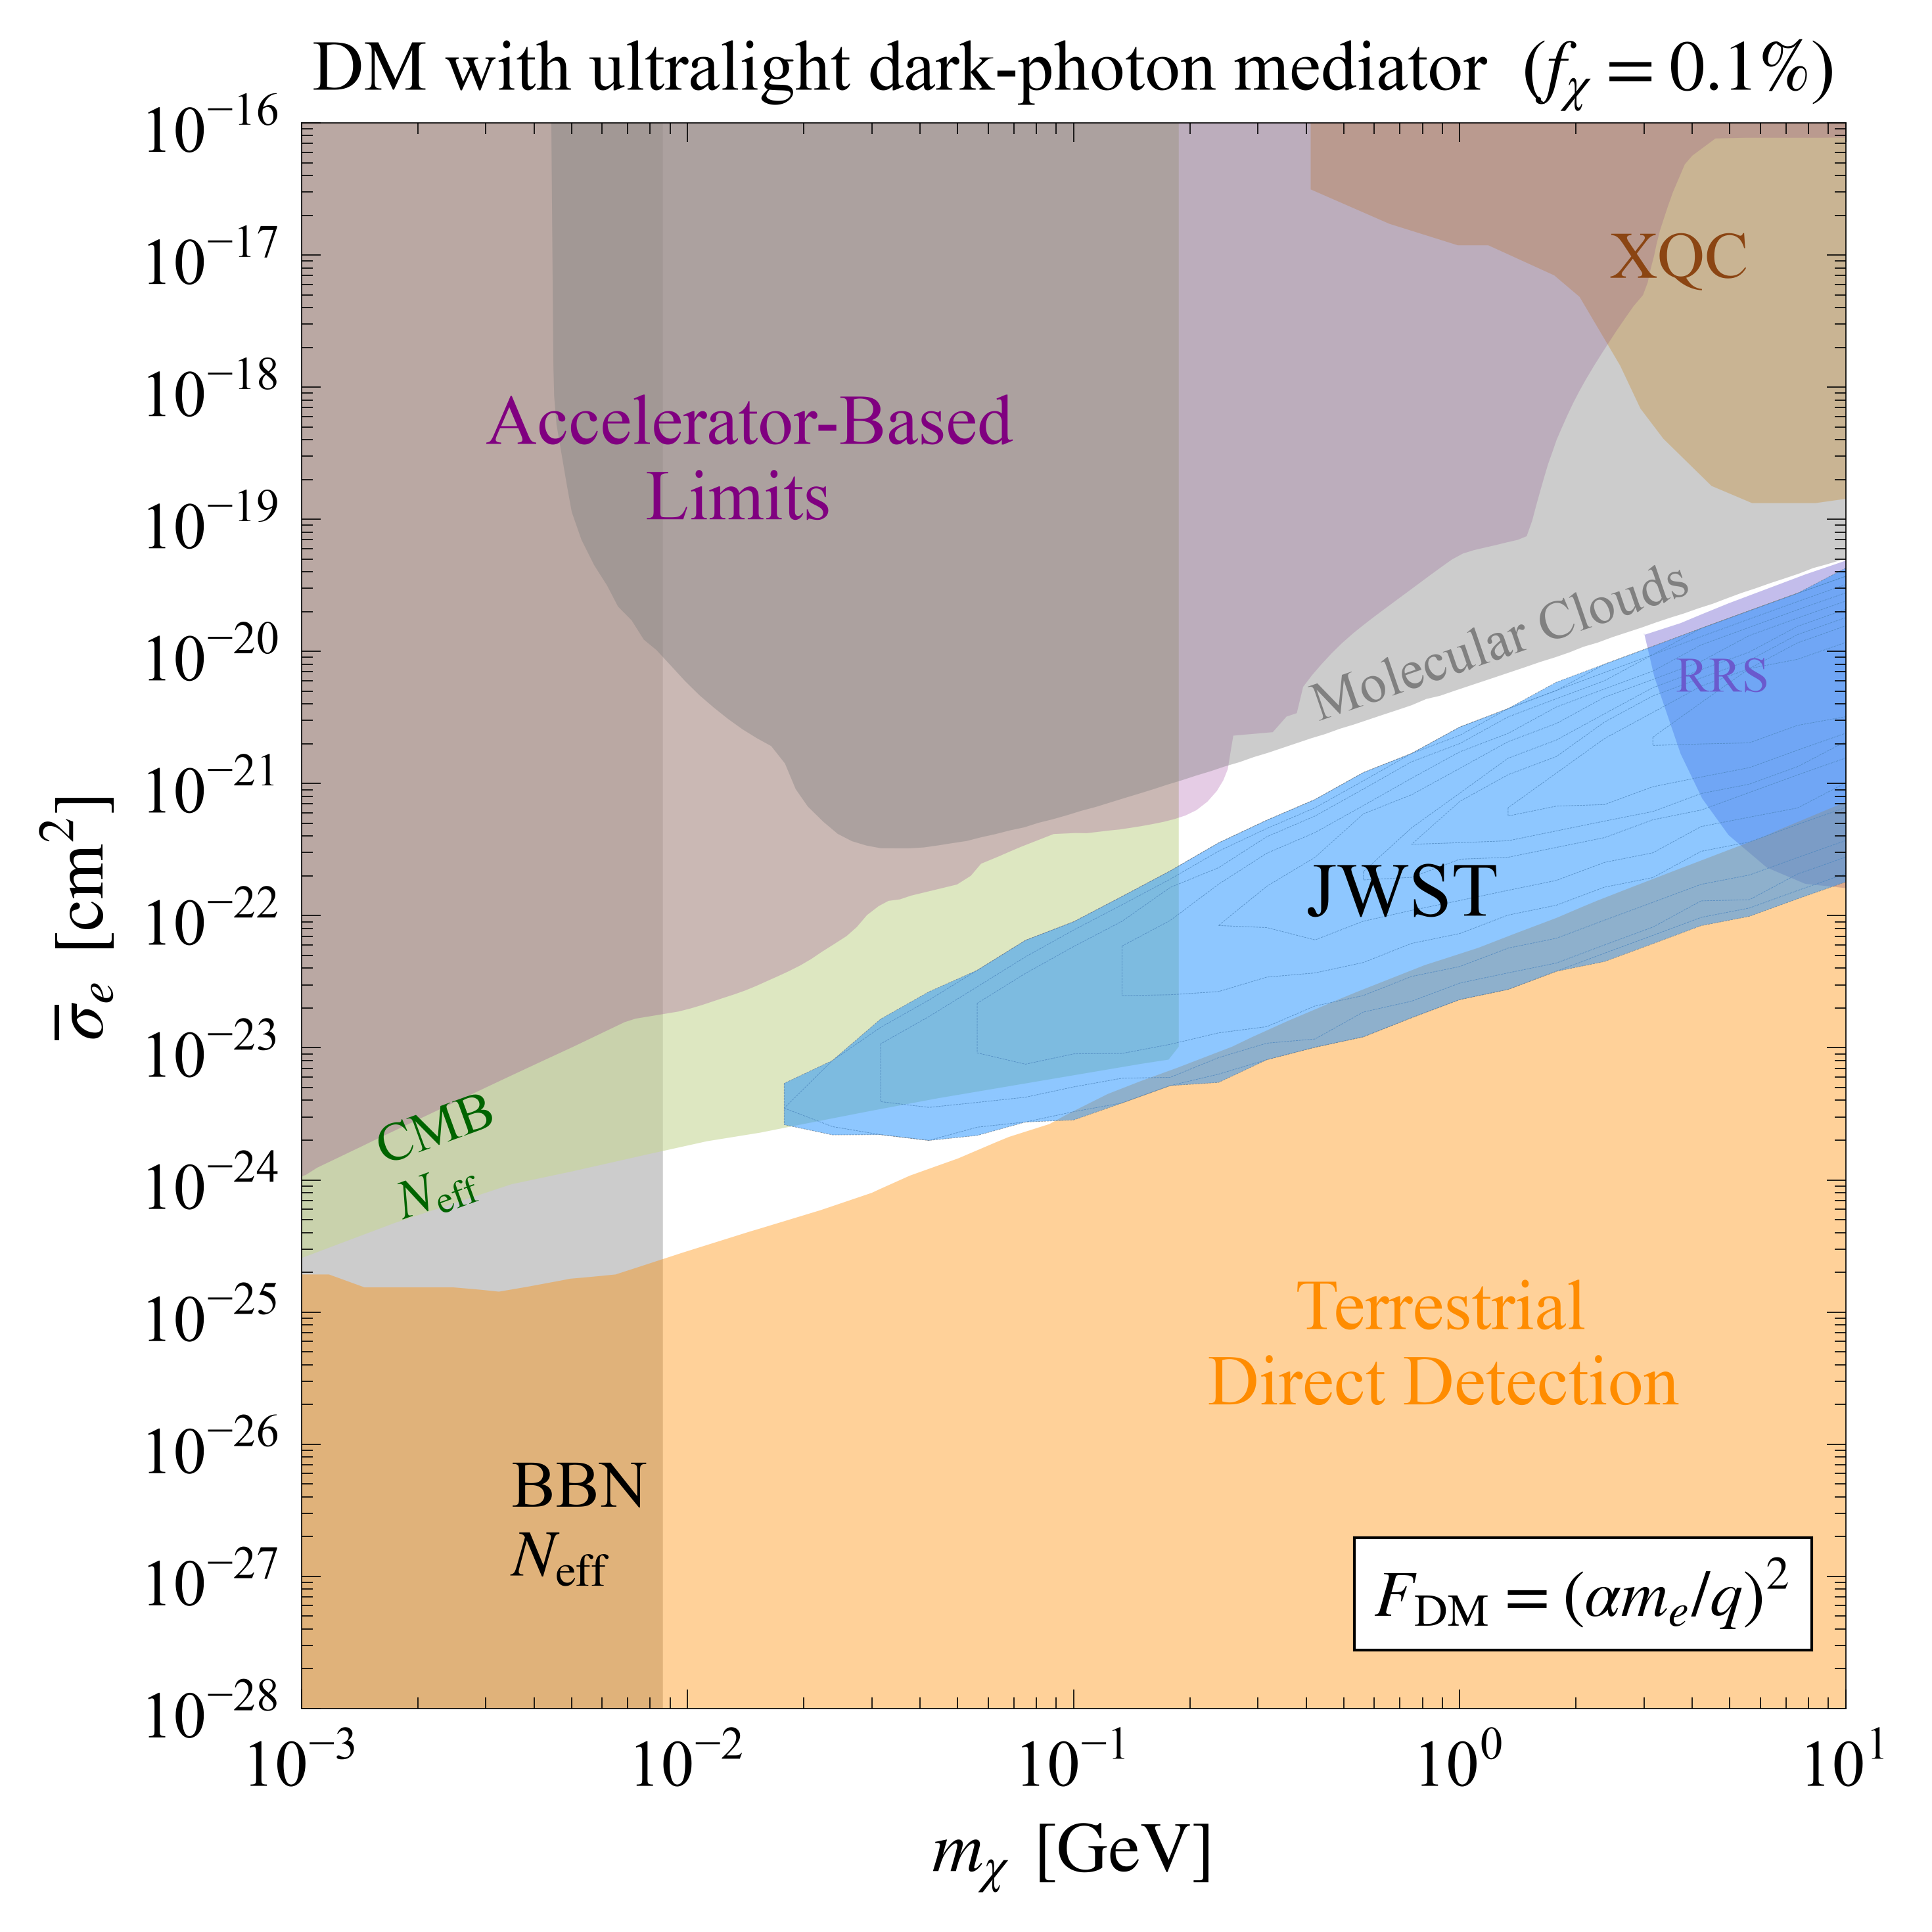

In [4]:
# 0.1%:
frac = '1e-3'
frac_rescale = float(frac) / 4e-3
output_dir = './advan_constraint/frac_' + frac + '/'
likelihood_output_dir = output_dir + 'log_likelihood_grid/'
constraint_grid_dir = output_dir + 'constraints/'
best_constraint_grid = np.zeros((n_cs,n_m))
for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_constraint_grid += constraint_grid
best_constraint_grid = (best_constraint_grid>0)
find_non_zero = np.sum(best_constraint_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_upper_limit = np.zeros((n_m - constraint_start, 2))
best_lower_limit = np.zeros((n_m - constraint_start, 2))
for col in range(constraint_start, n_m):
    indices = np.where(best_constraint_grid[:, col] == 1)[0]
    upper_index = n_cs -1 - np.min(indices)
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_upper_limit[index_temp, 0] = m_grid[col]
    best_lower_limit[index_temp, 0] = m_grid[col]
    best_upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
    best_lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]

fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
ax.fill_between(XQC[:,0], XQC[:,1] / frac_rescale, plt_ymax, color='#FBCF89', alpha=0.8, edgecolor=None)
RRS_x_points = np.array([3, 3.18949617, 3.73216038, 4.2441582 , 4.96626371, 6.24144805, 7.84406065, 9.85817506, 10])
ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points) / frac_rescale, color = 'slateblue', alpha=0.4, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color='purple', alpha=0.2, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)
ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1] / frac_rescale, plt_ymax, color= 'gray', alpha=0.4, edgecolor=None)

for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    if np.sum(constraint_grid) == 0:
        continue
    find_non_zero = np.sum(constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    # JWST Result, here:
    ax.fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1], facecolor='none', edgecolor='gray',alpha = 0.9, linestyle='--', linewidth=0.1) 
ax.fill_between(best_lower_limit[:,0], best_lower_limit[:,1], best_upper_limit[:,1], facecolor='dodgerblue', alpha = 0.5, edgecolor=None)

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.1\%$)', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.2, 2e-26, '      Terrestrial\n Direct Detection', fontsize=13, color='darkorange',rotation=0)
ax.text(3e-3, 1e-19, 'Accelerator-Based\n         Limits', fontsize=13, color='purple',alpha=1,rotation=0)
ax.text(3.5e-3, 1e-27, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(1.5, 2e-18, '     XQC\n', fontsize=12, color='saddlebrown', rotation=0)
ax.text(2.5, 2e-21, '     RRS\n', fontsize=9, color='slateblue',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='darkgreen', alpha=1,rotation=20)
ax.text(4e-1, 3e-21, 'Molecular Clouds', fontsize=10, color= 'gray', alpha=1, rotation=19)
#ax.text(1.5e-1, 2.3e-21, 'molecular cloud (diffuse)', fontsize=10, color='black',rotation=19)
ax.text(4e-1, 1e-22, 'JWST', fontsize=14, color='black',rotation=0)  
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
plt.savefig('constraints_' + frac + '.pdf', format="pdf",bbox_inches="tight")
plt.show()

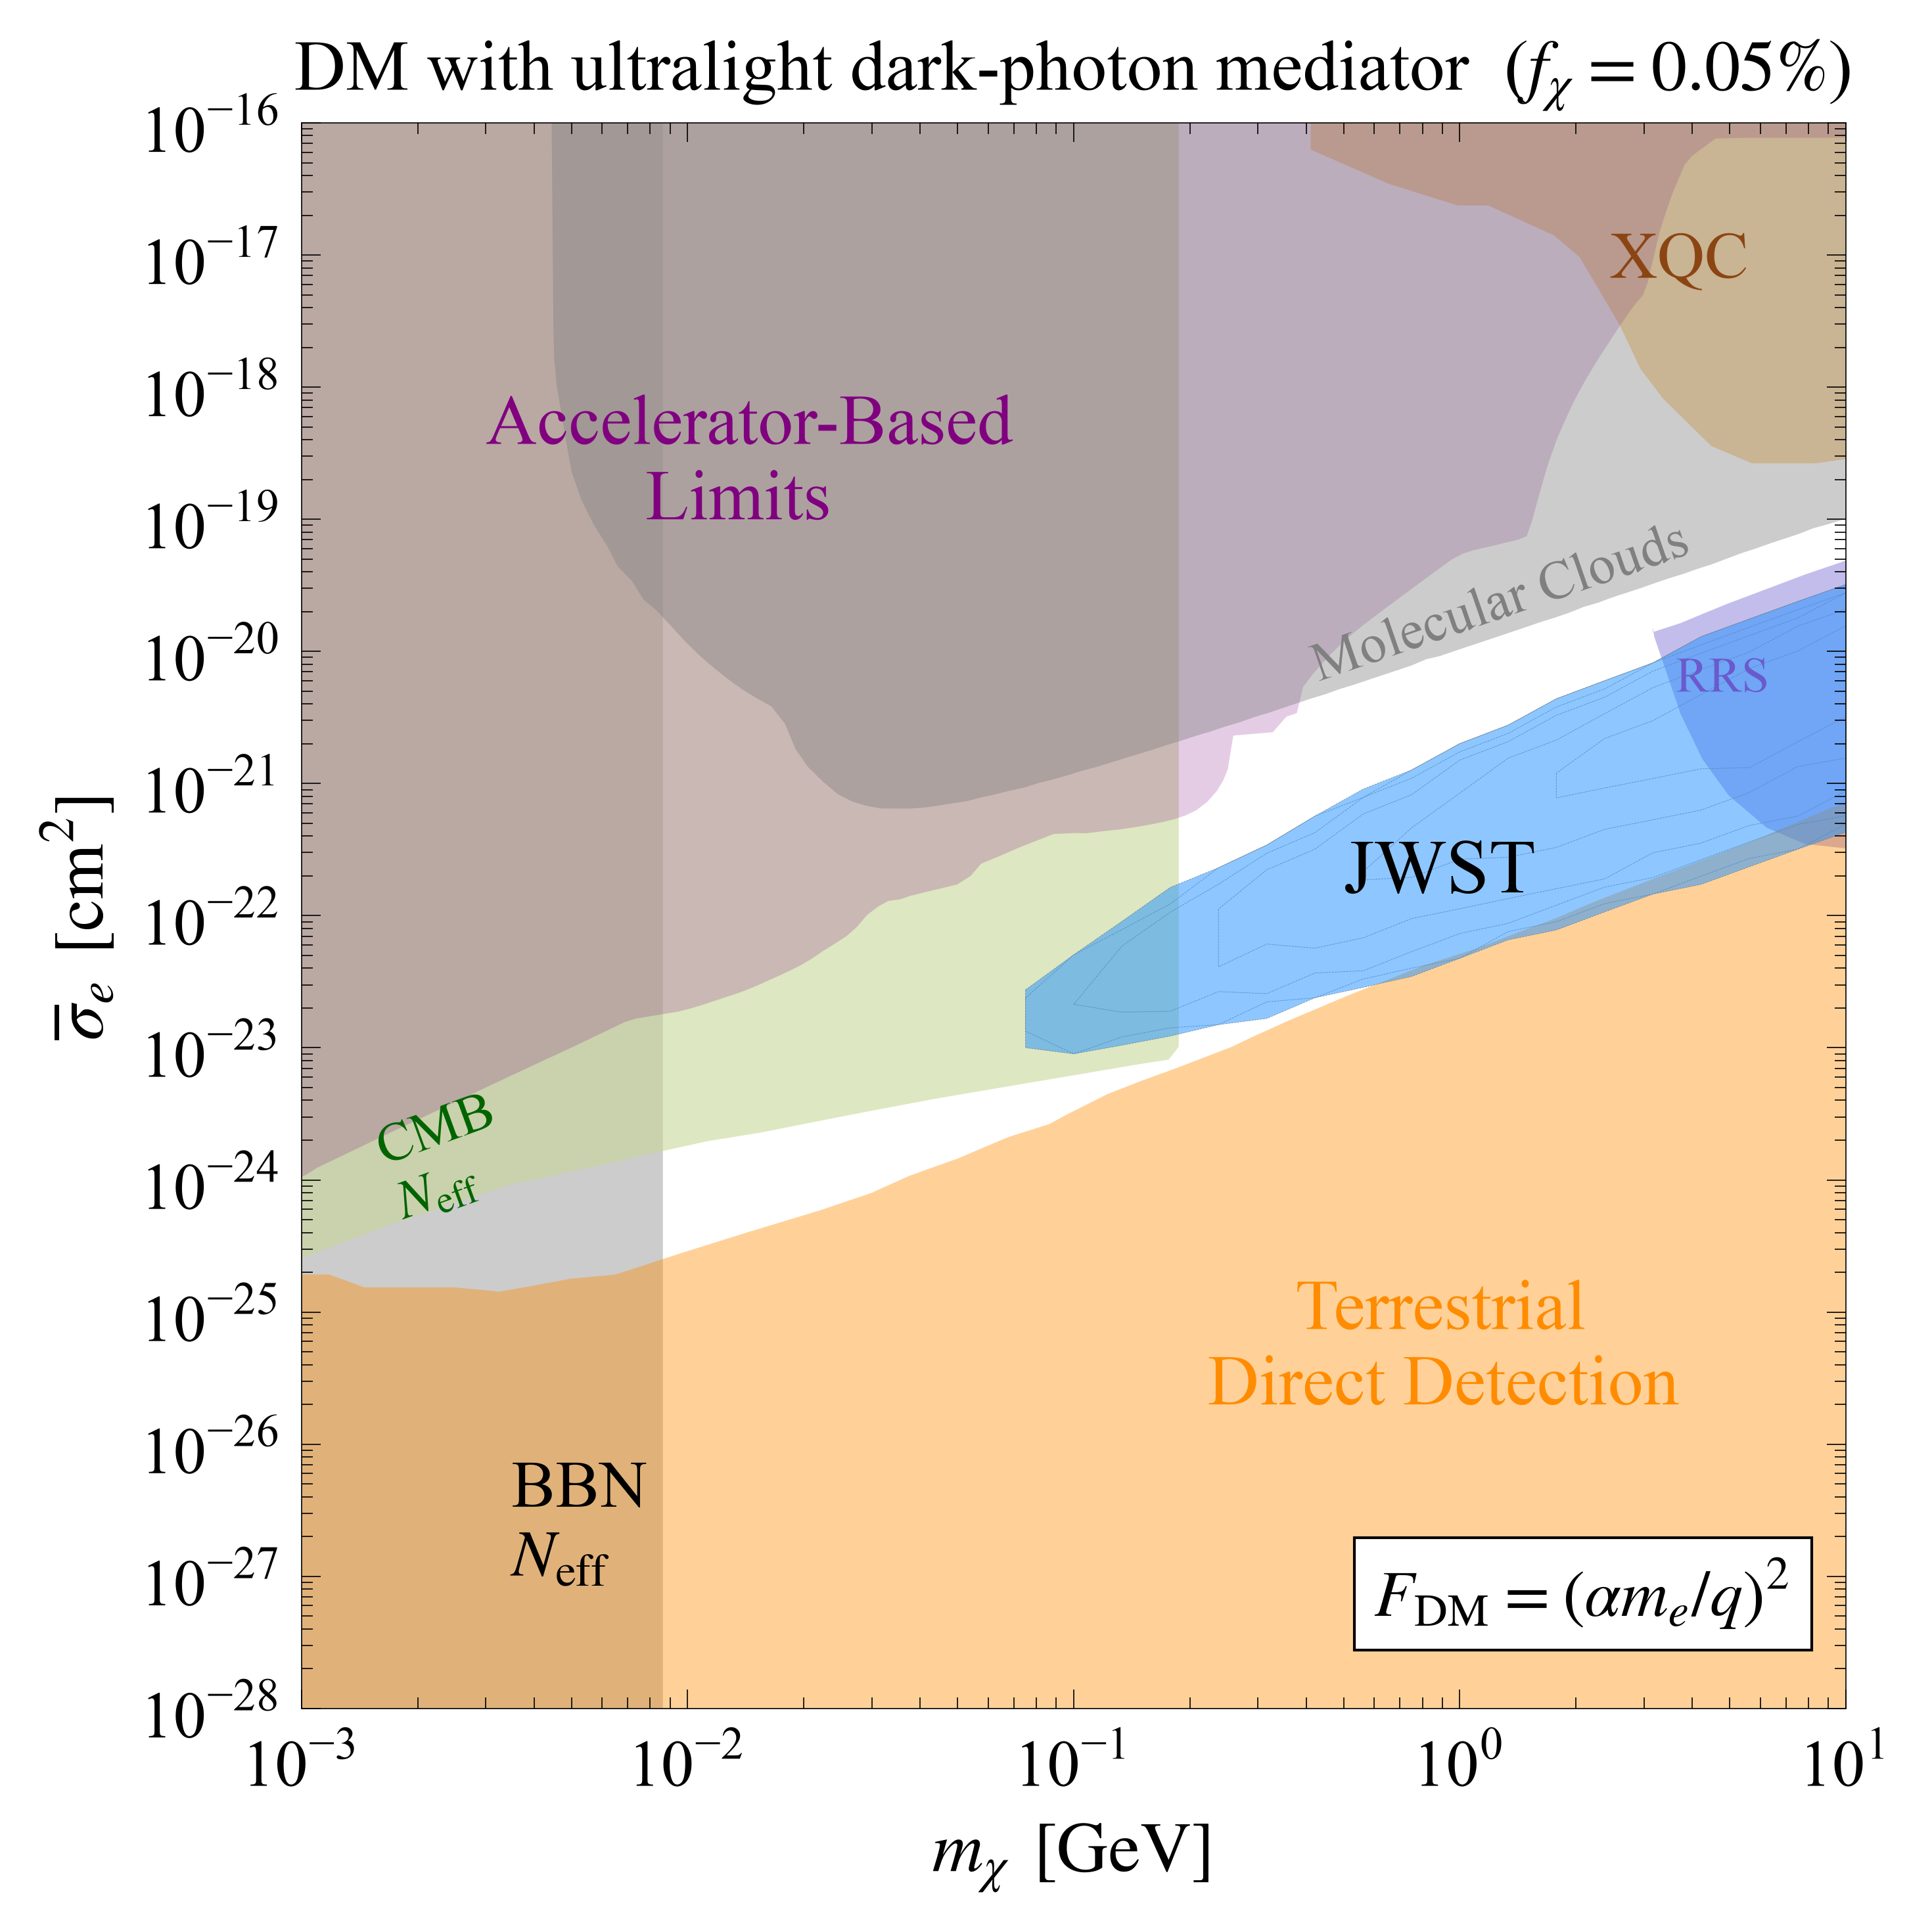

In [5]:
# 0.05%:
frac = '5e-4'
frac_rescale = float(frac) / 4e-3
output_dir = './advan_constraint/frac_' + frac + '/'
likelihood_output_dir = output_dir + 'log_likelihood_grid/'
constraint_grid_dir = output_dir + 'constraints/'
best_constraint_grid = np.zeros((n_cs,n_m))
for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_constraint_grid += constraint_grid
best_constraint_grid = (best_constraint_grid>0)
find_non_zero = np.sum(best_constraint_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_upper_limit = np.zeros((n_m - constraint_start, 2))
best_lower_limit = np.zeros((n_m - constraint_start, 2))
for col in range(constraint_start, n_m):
    indices = np.where(best_constraint_grid[:, col] == 1)[0]
    upper_index = n_cs -1 - np.min(indices)
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_upper_limit[index_temp, 0] = m_grid[col]
    best_lower_limit[index_temp, 0] = m_grid[col]
    best_upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
    best_lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]

#plot parameters
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16

fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
ax.fill_between(XQC[:,0], XQC[:,1] / frac_rescale, plt_ymax, color='#FBCF89', alpha=0.8, edgecolor=None)
RRS_x_points = np.array([3.16, 3.18949617, 3.73216038, 4.2441582 , 4.96626371, 6.24144805, 7.84406065, 9.85817506, 10])
ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points) / frac_rescale, color = 'slateblue', alpha=0.4, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color='purple', alpha=0.2, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)
ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1] / frac_rescale, plt_ymax, color= 'gray', alpha=0.4, edgecolor=None)

for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    if np.sum(constraint_grid) == 0:
        continue
    find_non_zero = np.sum(constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    # JWST Result, here:
    ax.fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1], facecolor='none', edgecolor='gray',alpha = 0.9, linestyle='--', linewidth=0.1) 
ax.fill_between(best_lower_limit[:,0], best_lower_limit[:,1], best_upper_limit[:,1], facecolor='dodgerblue', alpha = 0.5, edgecolor=None)

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.05\%$)', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.2, 2e-26, '      Terrestrial\n Direct Detection', fontsize=13, color='darkorange',rotation=0)
ax.text(3e-3, 1e-19, 'Accelerator-Based\n         Limits', fontsize=13, color='purple',alpha=1,rotation=0)
ax.text(3.5e-3, 1e-27, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(1.5, 2e-18, '     XQC\n', fontsize=12, color='saddlebrown', rotation=0)
ax.text(2.5, 2e-21, '     RRS\n', fontsize=9, color='slateblue',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='darkgreen', alpha=1,rotation=20)
ax.text(4e-1, 6e-21, 'Molecular Clouds', fontsize=10, color= 'gray', alpha=1, rotation=19)
#ax.text(1.5e-1, 2.3e-21, 'molecular cloud (diffuse)', fontsize=10, color='black',rotation=19)
ax.text(5e-1, 1.5e-22, 'JWST', fontsize=14, color='black',rotation=0)  
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
plt.savefig('constraints_' + frac + '.pdf', format="pdf",bbox_inches="tight")
plt.show()

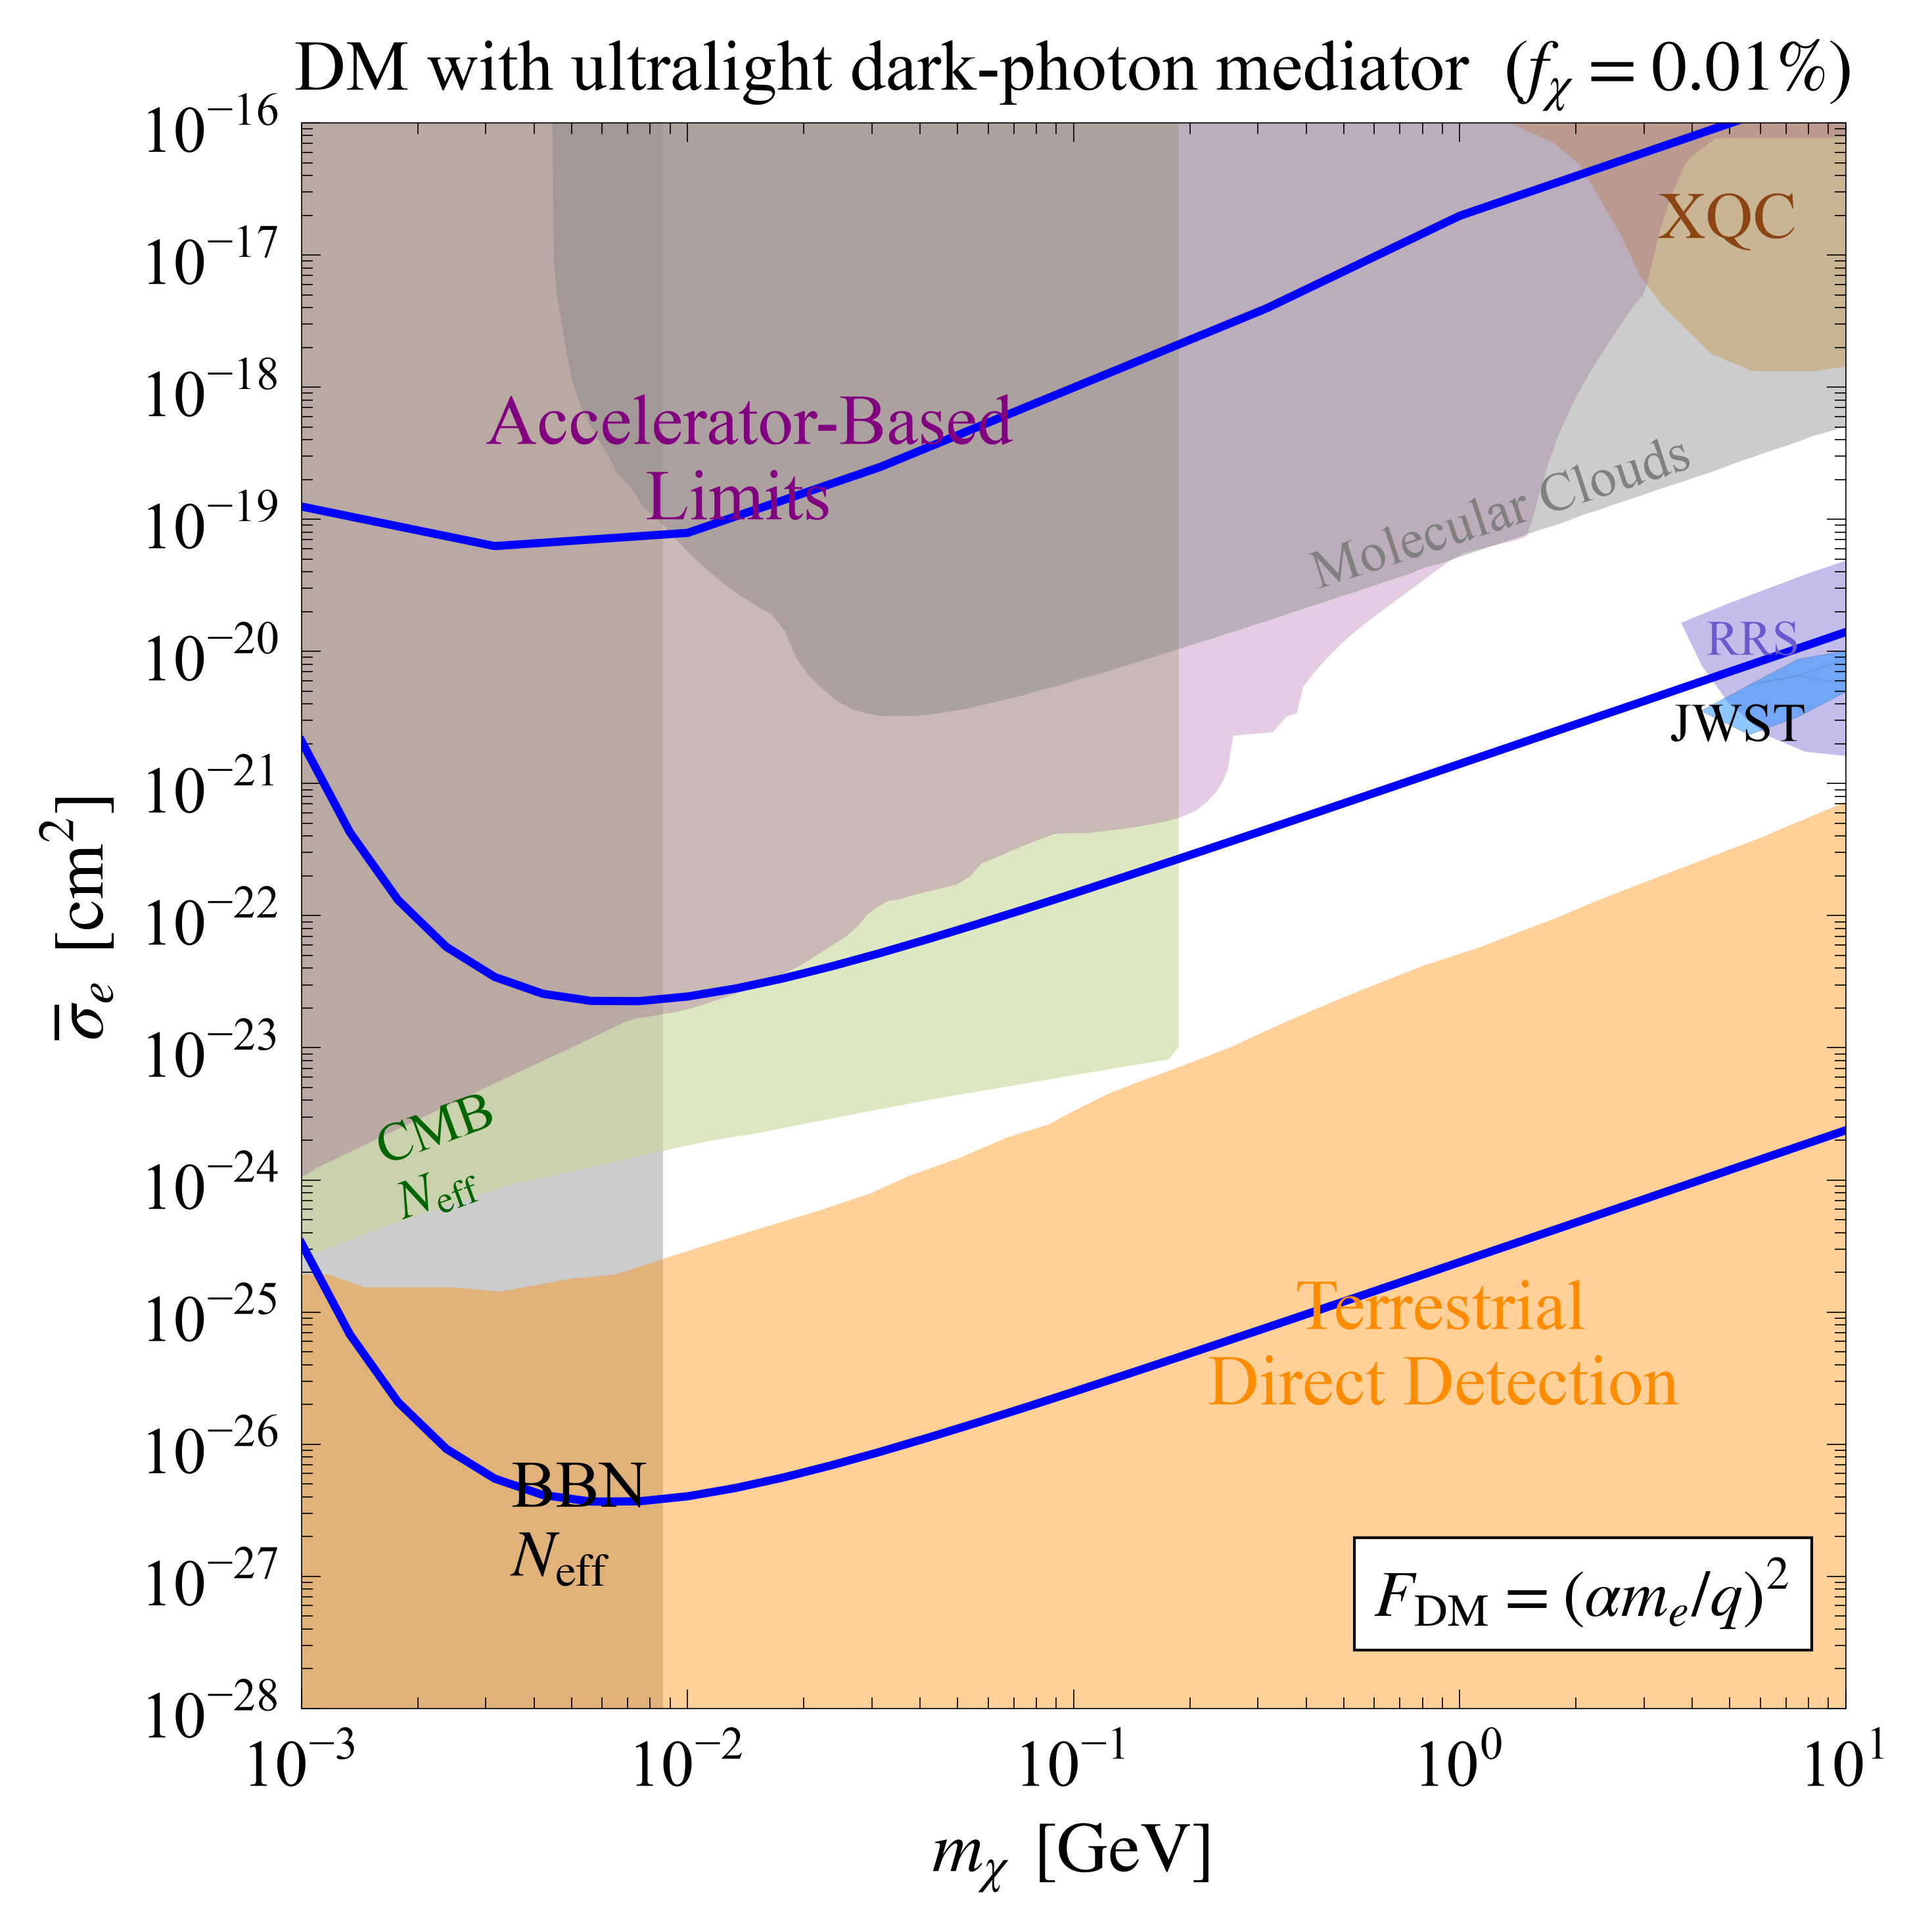

In [6]:
# 0.01%:
frac = '1e-4'
frac_rescale = float(frac) / 4e-3
output_dir = './advan_constraint/frac_' + frac + '/'
likelihood_output_dir = output_dir + 'log_likelihood_grid/'
constraint_grid_dir = output_dir + 'constraints/'
best_constraint_grid = np.zeros((n_cs,n_m))
for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_constraint_grid += constraint_grid
best_constraint_grid = (best_constraint_grid>0)
find_non_zero = np.sum(best_constraint_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_upper_limit = np.zeros((n_m - constraint_start, 2))
best_lower_limit = np.zeros((n_m - constraint_start, 2))
for col in range(constraint_start, n_m):
    indices = np.where(best_constraint_grid[:, col] == 1)[0]
    upper_index = n_cs -1 - np.min(indices)
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_upper_limit[index_temp, 0] = m_grid[col]
    best_lower_limit[index_temp, 0] = m_grid[col]
    best_upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
    best_lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]

#plot parameters
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16

fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
ax.fill_between(XQC[:,0], XQC[:,1] / frac_rescale, plt_ymax, color='#FBCF89', alpha=0.8, edgecolor=None)
RRS_x_points = np.array([3.73216038, 4.2441582 , 4.96626371, 6.24144805, 7.84406065, 9.85817506, 10])
ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points) / frac_rescale, color = 'slateblue', alpha=0.4, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color='purple', alpha=0.2, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)
ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1] / frac_rescale, plt_ymax, color= 'gray', alpha=0.4, edgecolor=None)

for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    if np.sum(constraint_grid) == 0:
        continue
    find_non_zero = np.sum(constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    # JWST Result, here:
    ax.fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1], facecolor='none', edgecolor='gray',alpha = 0.9, linestyle='--', linewidth=0.1) 
ax.fill_between(best_lower_limit[:,0], best_lower_limit[:,1], best_upper_limit[:,1], facecolor='dodgerblue', alpha = 0.5, edgecolor=None)

ax.loglog(darkness_upper[:,0],darkness_upper[:,2], color='blue')
ax.loglog(darkness_rate[:,0],darkness_rate[:,1], color='blue')
ax.loglog(darkness_mod[:,0],darkness_mod[:,1], color='blue')

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.01\%$)', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.2, 2e-26, '      Terrestrial\n Direct Detection', fontsize=13, color='darkorange',rotation=0)
ax.text(3e-3, 1e-19, 'Accelerator-Based\n         Limits', fontsize=13, color='purple',alpha=1,rotation=0)
ax.text(3.5e-3, 1e-27, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(2, 4e-18, '     XQC\n', fontsize=12, color='saddlebrown', rotation=0)
ax.text(3, 3.8e-21, '     RRS\n', fontsize=9, color='slateblue',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='darkgreen', alpha=1,rotation=20)
ax.text(4e-1, 3e-20, 'Molecular Clouds', fontsize=10, color= 'gray', alpha=1, rotation=18)
#ax.text(1.5e-1, 2.3e-21, 'molecular cloud (diffuse)', fontsize=10, color='black',rotation=19)
ax.text(3.5, 2.1e-21, 'JWST', fontsize=10, color='black',rotation=0)  
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
plt.savefig('constraints_' + frac + '.pdf', format="pdf",bbox_inches="tight")
plt.show()

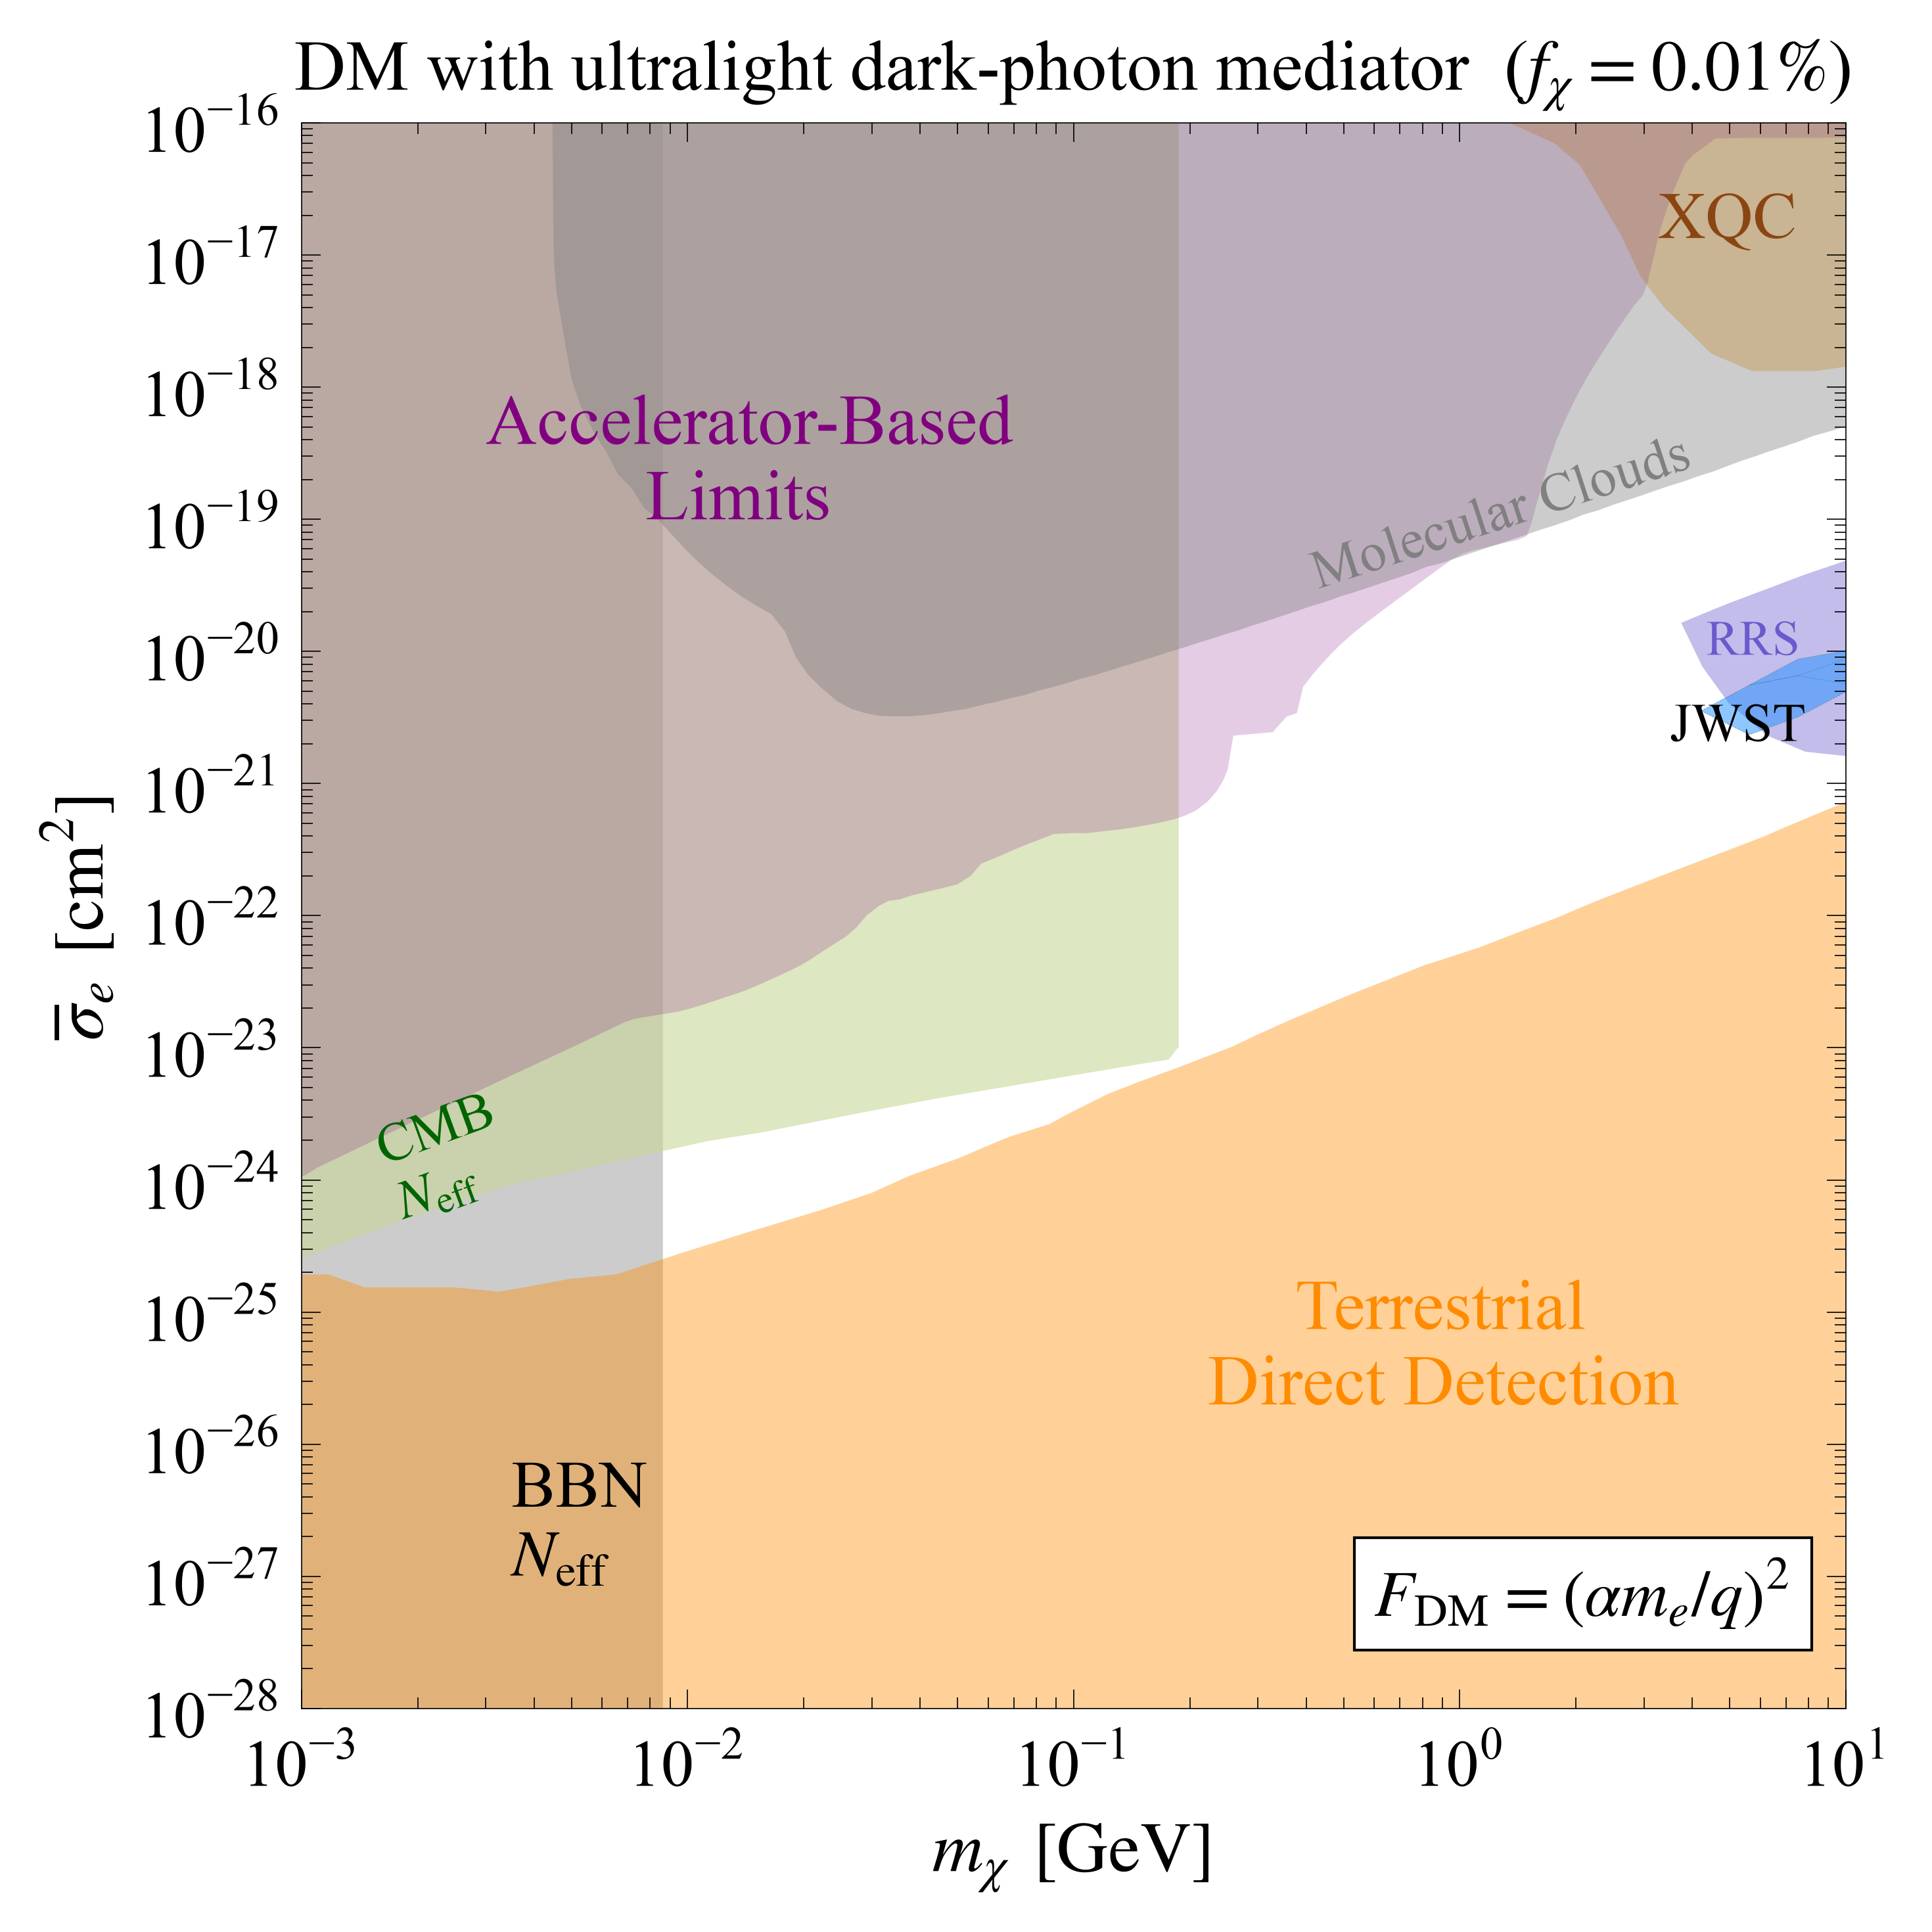

In [7]:
# 0.02%:
frac = '1e-4'
frac_rescale = float(frac) / 4e-3
output_dir = './advan_constraint/frac_' + frac + '/'
likelihood_output_dir = output_dir + 'log_likelihood_grid/'
constraint_grid_dir = output_dir + 'constraints/'
best_constraint_grid = np.zeros((n_cs,n_m))
for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_constraint_grid += constraint_grid
best_constraint_grid = (best_constraint_grid>0)
find_non_zero = np.sum(best_constraint_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_upper_limit = np.zeros((n_m - constraint_start, 2))
best_lower_limit = np.zeros((n_m - constraint_start, 2))
for col in range(constraint_start, n_m):
    indices = np.where(best_constraint_grid[:, col] == 1)[0]
    upper_index = n_cs -1 - np.min(indices)
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_upper_limit[index_temp, 0] = m_grid[col]
    best_lower_limit[index_temp, 0] = m_grid[col]
    best_upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
    best_lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]

#plot parameters
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16

fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
ax.fill_between(XQC[:,0], XQC[:,1] / frac_rescale, plt_ymax, color='#FBCF89', alpha=0.8, edgecolor=None)
RRS_x_points = np.array([3.73216038, 4.2441582 , 4.96626371, 6.24144805, 7.84406065, 9.85817506, 10])
ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points) / frac_rescale, color = 'slateblue', alpha=0.4, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color='purple', alpha=0.2, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)
ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1] / frac_rescale, plt_ymax, color= 'gray', alpha=0.4, edgecolor=None)

for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    if np.sum(constraint_grid) == 0:
        continue
    find_non_zero = np.sum(constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    # JWST Result, here:
    ax.fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1], facecolor='none', edgecolor='gray',alpha = 0.9, linestyle='--', linewidth=0.1) 
ax.fill_between(best_lower_limit[:,0], best_lower_limit[:,1], best_upper_limit[:,1], facecolor='dodgerblue', alpha = 0.5, edgecolor=None)

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator  ' + r'($f_{\chi}=0.01\%$)', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.2, 2e-26, '      Terrestrial\n Direct Detection', fontsize=13, color='darkorange',rotation=0)
ax.text(3e-3, 1e-19, 'Accelerator-Based\n         Limits', fontsize=13, color='purple',alpha=1,rotation=0)
ax.text(3.5e-3, 1e-27, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(2, 4e-18, '     XQC\n', fontsize=12, color='saddlebrown', rotation=0)
ax.text(3, 3.8e-21, '     RRS\n', fontsize=9, color='slateblue',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='darkgreen', alpha=1,rotation=20)
ax.text(4e-1, 3e-20, 'Molecular Clouds', fontsize=10, color= 'gray', alpha=1, rotation=18)
#ax.text(1.5e-1, 2.3e-21, 'molecular cloud (diffuse)', fontsize=10, color='black',rotation=19)
ax.text(3.5, 2.1e-21, 'JWST', fontsize=10, color='black',rotation=0)  
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
plt.savefig('constraints_' + frac + '.pdf', format="pdf",bbox_inches="tight")
plt.show()

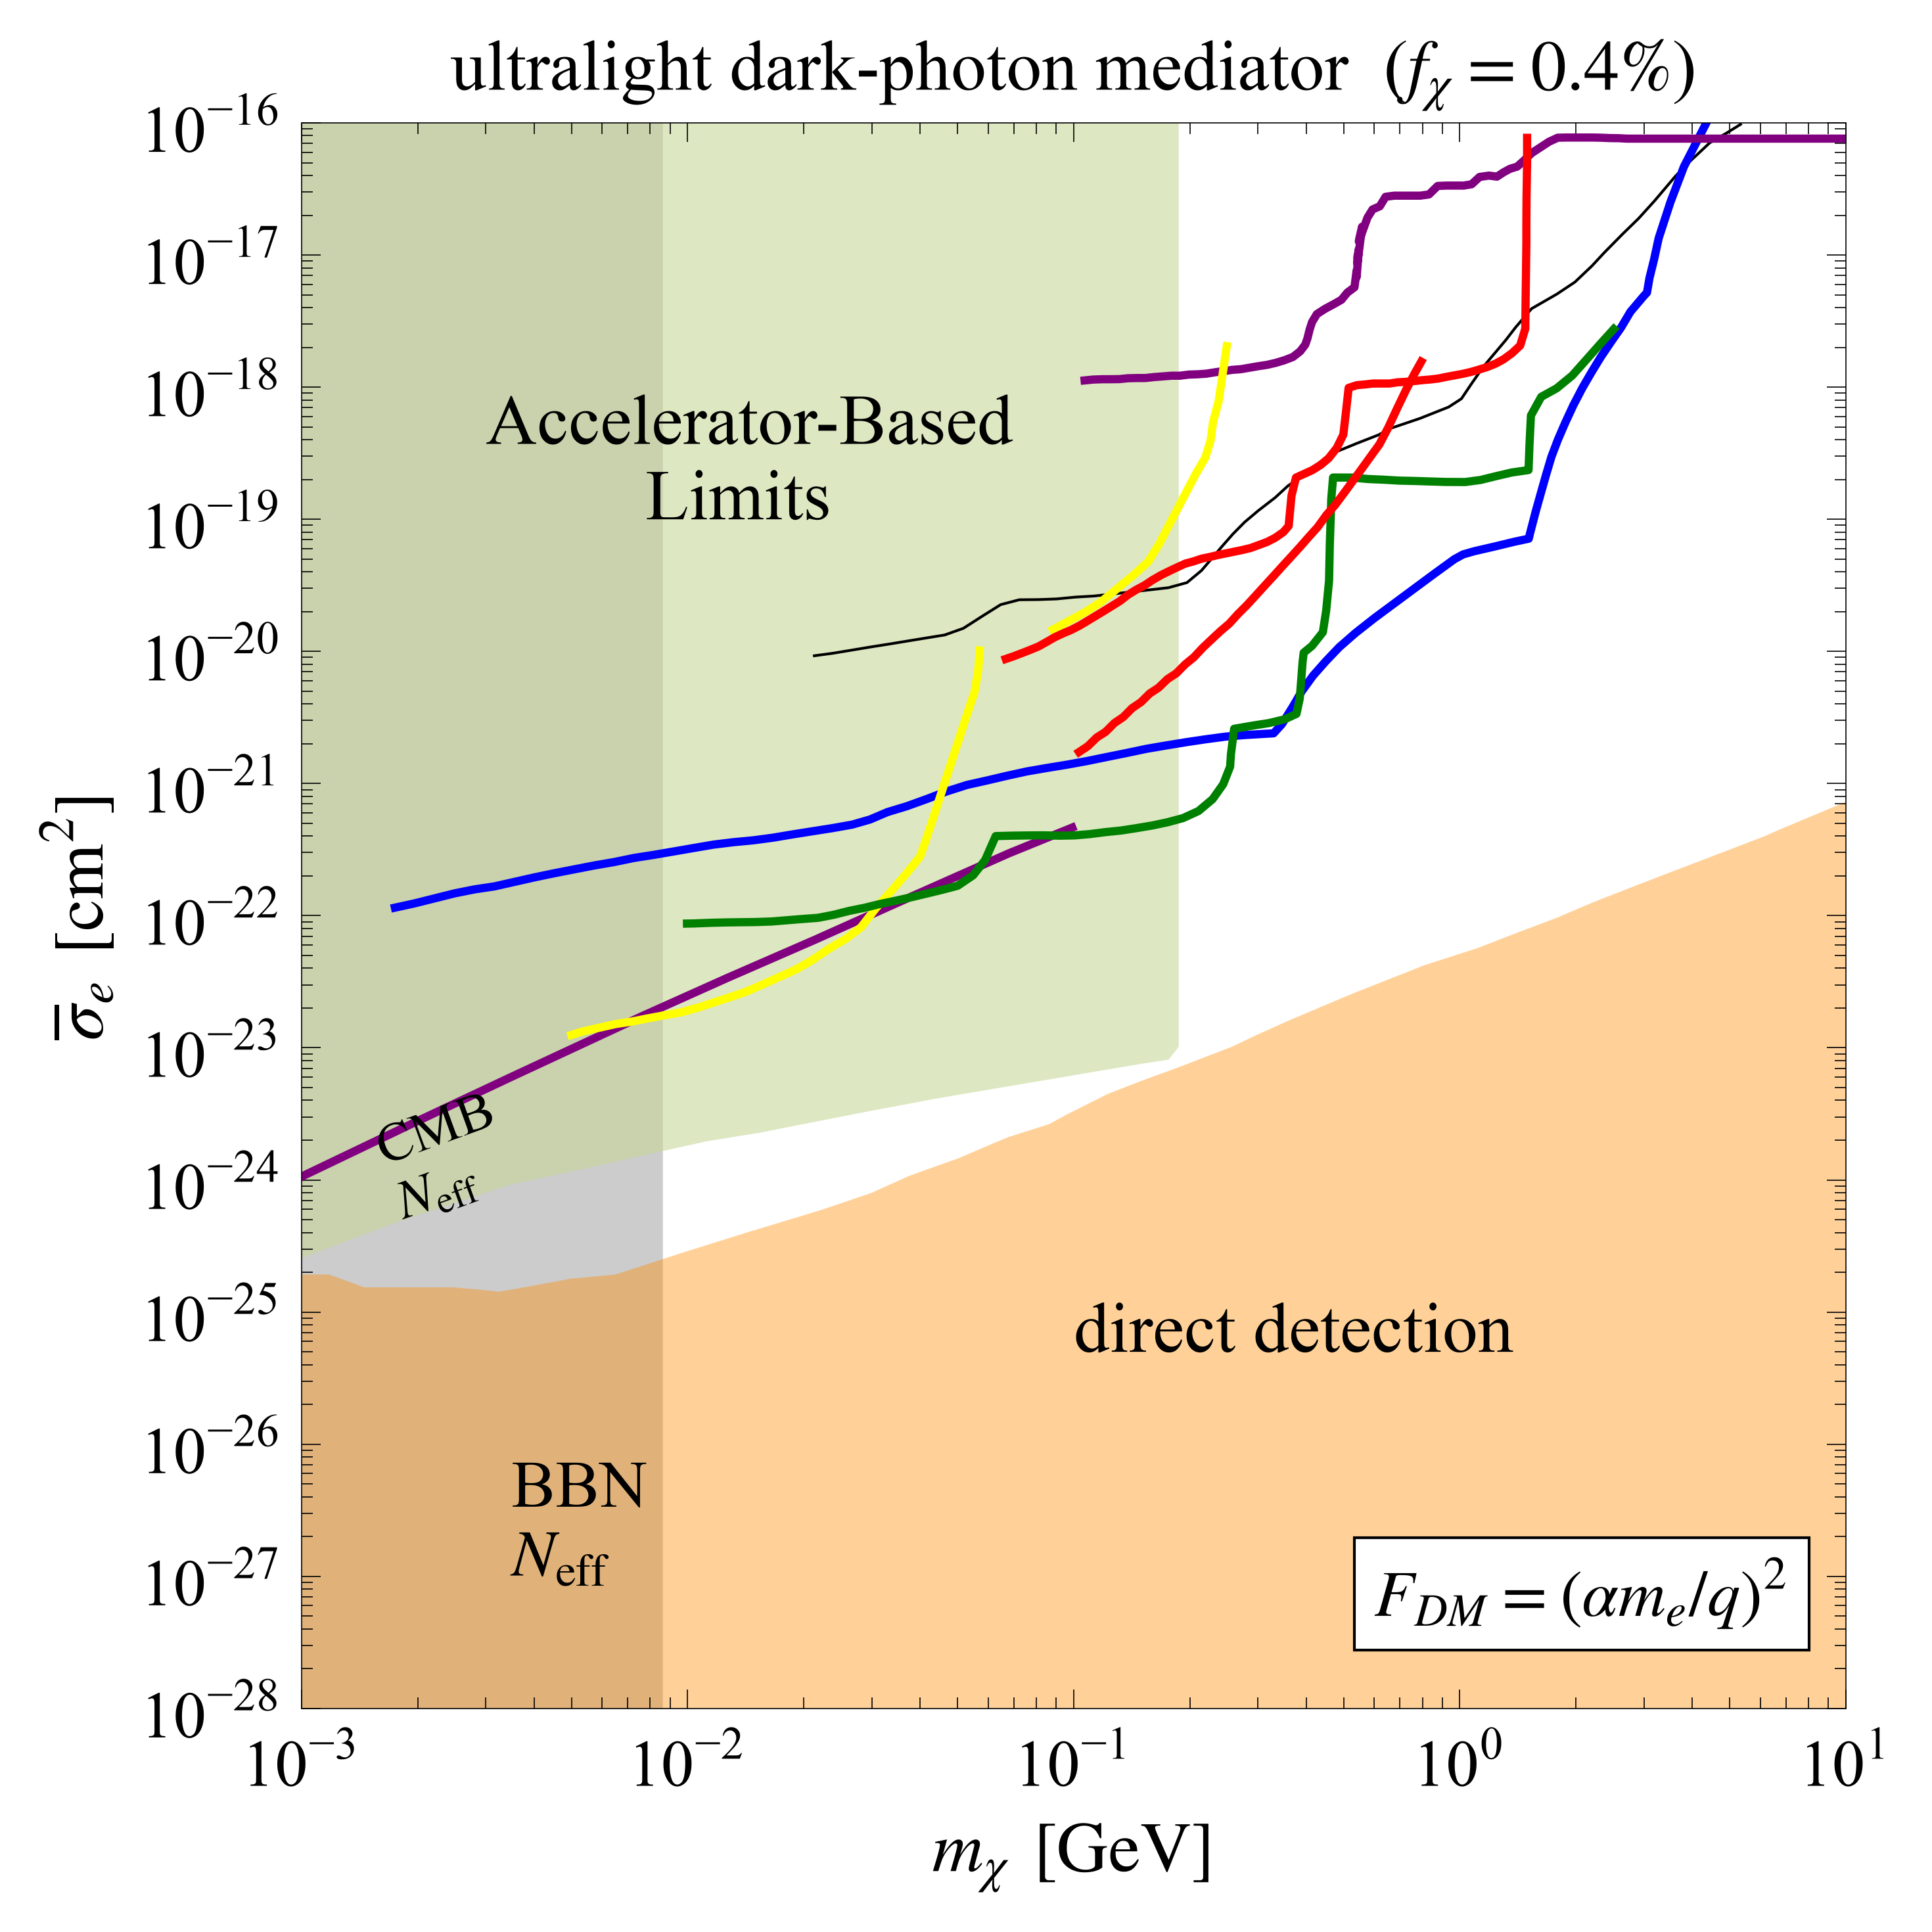

In [8]:
# dev: terrestrial limits compilation:
fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)

ax.loglog(ArgoNeuT[:,0],ArgoNeuT[:,1], color='black', linewidth = 0.5, alpha=1)
ax.loglog(BEBC[:,0],BEBC[:,1], color='blue', alpha=1)
ax.loglog(SLAC[:,0],SLAC[:,1], color='purple', alpha=1)
ax.loglog(LEP[:,0],LEP[:,1], color='purple', alpha=1)
ax.loglog(LSND[:,0],LSND[:,1], color='yellow', alpha=1)
ax.loglog(miniboone[:,0],miniboone[:,1], color='yellow', alpha=1)
ax.loglog(SENSEI[:,0],SENSEI[:,1], color='green', alpha=1)
ax.loglog(Super_K[:,0],Super_K[:,1], color='red', alpha=1)
ax.loglog(XENON1T_4e_3[:,0],XENON1T_4e_3[:,1], color='red', alpha=1)

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('ultralight dark-photon mediator  ' + r'($f_{\chi}=0.4\%$)', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.1, 5e-26, 'direct detection', fontsize=13, color='black',rotation=0)
ax.text(3e-3, 1e-19, 'Accelerator-Based\n         Limits', fontsize=13, color='black',rotation=0)
ax.text(3.5e-3, 1e-27, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='black',rotation=20)
#ax.text(1.5e-1, 2.3e-21, 'molecular cloud (diffuse)', fontsize=10, color='black',rotation=19)
ax.text(0.6, 0.5e-27, r'$F_{DM}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
#plt.savefig("main_result.pdf", format="pdf",bbox_inches="tight")
plt.show()

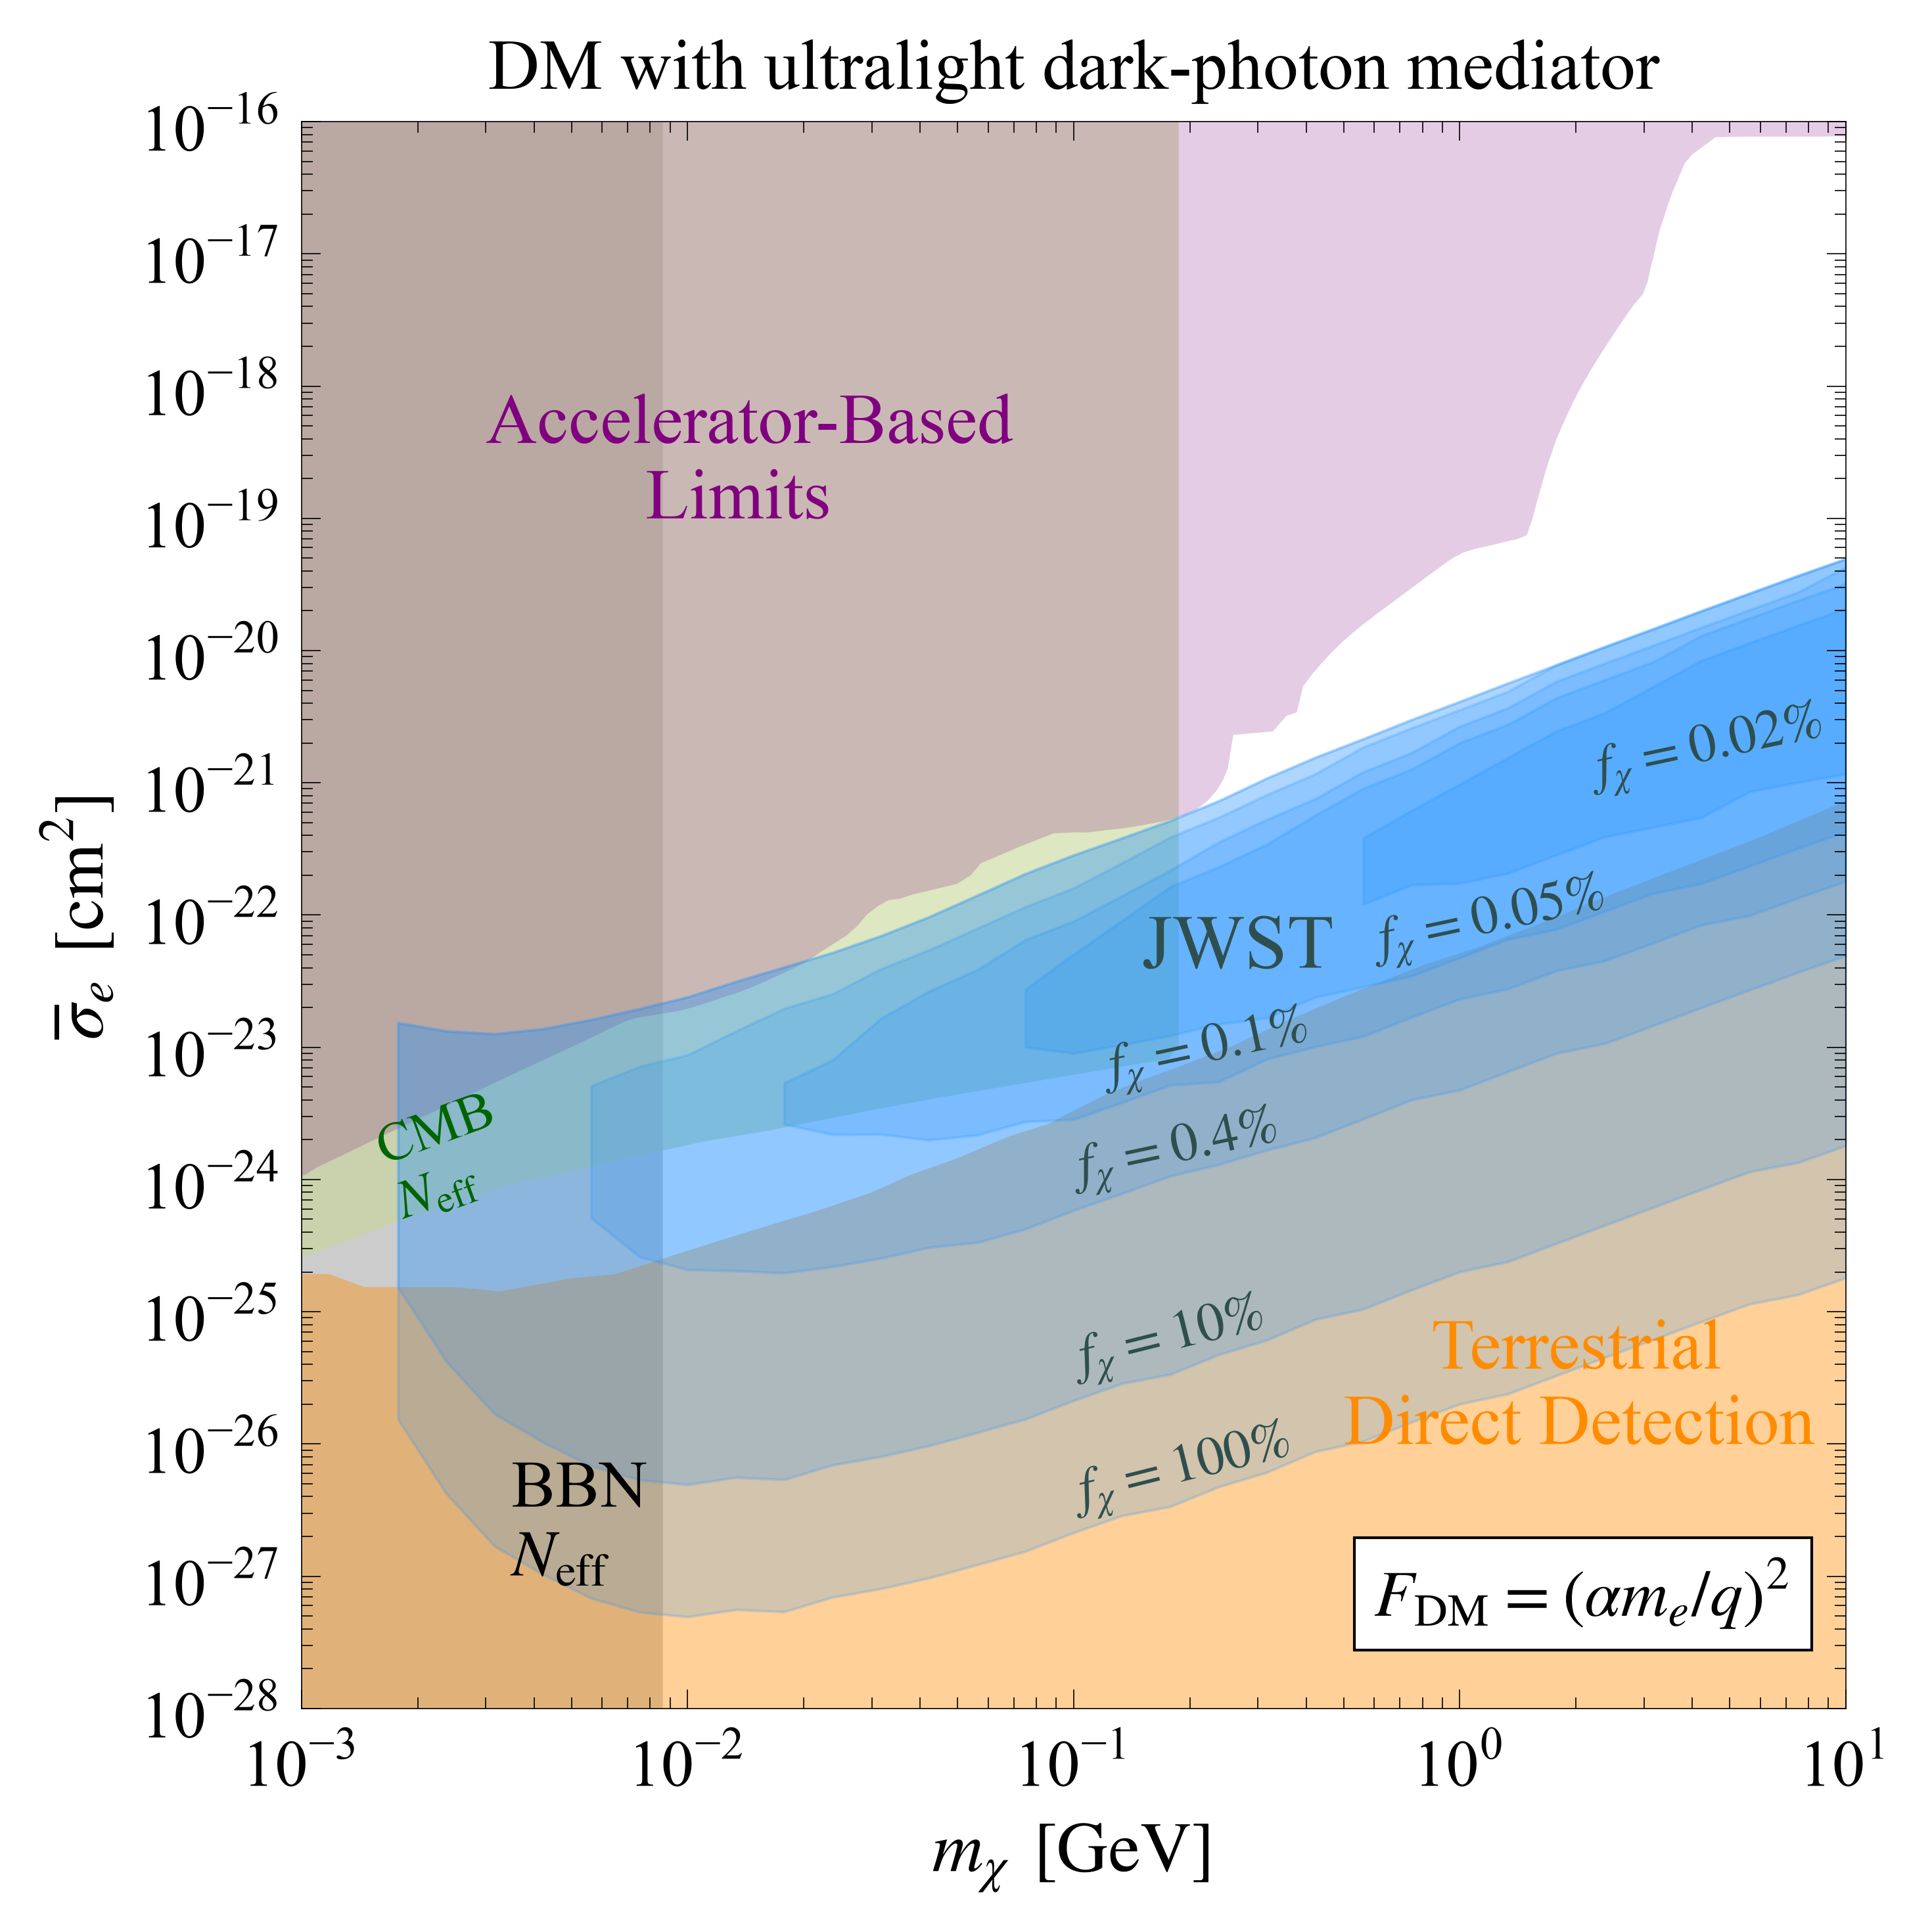

In [9]:
# different fractions:
#plot parameters
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16

fig, ax = plt.subplots(figsize = (5,5), dpi = 600)
#ax.loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
ax.loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='royalblue', alpha=1)
ax.fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='black', alpha=0.2, edgecolor=None)
ax.fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.6, edgecolor=None)
#ax.fill_between(XQC[:,0], XQC[:,1], plt_ymax, color='#FBCF89', alpha=0.8, edgecolor=None)
#ax.fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points), color = 'slateblue', alpha=0.4, edgecolor=None)
ax.fill_between(terrestrial_limits[:,0],terrestrial_limits[:,1], plt_ymax, color='purple', alpha=0.2, edgecolor=None)
ax.fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = 'darkorange', alpha=0.4, edgecolor=None)
#ax.fill_between(molecular_cloud_dense_upper[:,0],molecular_cloud_dense_upper[:,1], plt_ymax, color= 'gray', alpha=0.4)
#ax.fill_between(molecular_cloud_diffuse[:,0],molecular_cloud_diffuse[:,1], plt_ymax, color='blue', alpha=0.05)

different_fraction_path = ['./advan_constraint/frac_4e-3/constraints/', 
                           './advan_constraint/frac_1e-3/constraints/',
                           './advan_constraint/frac_5e-4/constraints/',
                           './advan_constraint/frac_2e-4/constraints/']
for path in different_fraction_path:
    overlay_constraint_grid = np.zeros((n_cs,n_m))
    for file in Path(path).iterdir():
        constraint_grid = np.loadtxt(file)
        overlay_constraint_grid += constraint_grid
    overlay_constraint_grid = (overlay_constraint_grid>0)
    find_non_zero = np.sum(overlay_constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(overlay_constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    # JWST Result, here:
    ax.fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1], facecolor='dodgerblue', alpha = 0.2, edgecolor='dodgerblue', linewidth = 0.5)

frac_1_dir_constraints_dir = './advan_constraint/frac_1/constraints/'
best_frac_1_grid = np.zeros((49,33))   # cs from 1e-6 to 1e-3 of center line
for file in Path(frac_1_dir_constraints_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    best_frac_1_grid += constraint_grid
best_frac_1_grid = (best_frac_1_grid>0)
find_non_zero = np.sum(best_frac_1_grid,axis=0)
constraint_start = np.min(np.where(find_non_zero != 0))
best_1_frac_limit = np.zeros((33 - constraint_start, 2))
for col in range(constraint_start, 33):
    indices = np.where(best_frac_1_grid[:, col] == 1)[0]
    lower_index = n_cs -1 - np.max(indices)
    index_temp = col - constraint_start
    best_1_frac_limit[index_temp, 0] = m_grid[col]
    best_1_frac_limit[index_temp, 1] = center_line[col] * 1e-3 * cs_grid[lower_index]
ax.fill_between(best_1_frac_limit[:,0], best_1_frac_limit[:,1], center_line[constraint_start:], facecolor='dodgerblue', alpha = 0.2, edgecolor='dodgerblue', linewidth = 0.5)
ax.fill_between(best_1_frac_limit[:,0], best_1_frac_limit[:,1] * 10, center_line[constraint_start:], facecolor='dodgerblue', alpha = 0.2, edgecolor='dodgerblue', linewidth = 0.5)

#作图参数
plt_xmin = 1e-3
plt_xmax = 10
plt_ymin = 1e-28
plt_ymax = 1e-16
ax.set_title('DM with ultralight dark-photon mediator', fontsize=13)
ax.set_xlim([plt_xmin, plt_xmax]) # in GeV
ax.set_ylim([plt_ymin ,plt_ymax]) # in cm2
ax.set_xlabel(r'$m_\chi~[\text{GeV}]$', fontsize=13, color='black')  # 设置 x 轴标签
ax.set_ylabel(r'$\overline{\sigma}_e~[\text{cm}^2]$', fontsize=13, color='black')  # 设置 y 轴标签
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = 'auto'))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs = np.arange(2, 10), numticks=2000))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis="both", direction="in", which = 'major', top=True, right=True, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=True, right=True, width = 0.2)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
ax.text(0.45, 1e-26, '      Terrestrial\n Direct Detection', fontsize=13, color='darkorange',rotation=0)
ax.text(3e-3, 1e-19, 'Accelerator-Based\n         Limits', fontsize=13, color='purple',alpha=1,rotation=0)
ax.text(3.5e-3, 1e-27, 'BBN\n' + r'$N_{\text{eff}}$', fontsize=12, color='black',rotation=0)
ax.text(1.5e-3, 5.1e-25, 'CMB\n' + r'$N_{\text{eff}}$', fontsize=10, color='darkgreen', alpha=1,rotation=20)
ax.text(0.1, 3.4e-27, r'$f_{\chi}=100\%$', fontsize=10, color='darkslategray',rotation=14)
ax.text(0.1, 3.5e-26, r'$f_{\chi}=10\%$', fontsize=10, color='darkslategray',rotation=14)
ax.text(0.1, 9.6e-25, r'$f_{\chi}=0.4\%$', fontsize=10, color='darkslategray',rotation=12)
ax.text(0.12, 5.5e-24, r'$f_{\chi}=0.1\%$', fontsize=10, color='darkslategray',rotation=12)
ax.text(0.6, 5e-23, r'$f_{\chi}=0.05\%$', fontsize=10, color='darkslategray',rotation=12)
ax.text(2.2, 1e-21, r'$f_{\chi}=0.02\%$', fontsize=10, color='darkslategray',rotation=12)  
ax.text(1.5e-1, 4e-23, 'JWST', fontsize=14, color='darkslategray',rotation=0)  
ax.text(0.6, 0.5e-27, r'$F_{\text{DM}}=(\alpha m_e/q)^2$', fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
plt.tight_layout()
plt.savefig("constraints_different_fractions.pdf", format="pdf",bbox_inches="tight")
plt.show()

In [10]:
best_1_frac_limit

array([[1.77827941e-03, 1.53030461e-26],
       [2.37137371e-03, 4.19754507e-27],
       [3.16227766e-03, 1.68502631e-27],
       [4.21696503e-03, 1.03402459e-27],
       [5.62341325e-03, 6.81753068e-28],
       [7.49894209e-03, 5.35400431e-28],
       [1.00000000e-02, 4.92863490e-28],
       [1.33352143e-02, 5.58623530e-28],
       [1.77827941e-02, 5.38118839e-28],
       [2.37137371e-02, 6.93378737e-28],
       [3.16227766e-02, 8.03436406e-28],
       [4.21696503e-02, 9.69011074e-28],
       [5.62341325e-02, 1.22064032e-27],
       [7.49894209e-02, 1.54304599e-27],
       [1.00000000e-01, 2.13358832e-27],
       [1.33352143e-01, 2.86617637e-27],
       [1.77827941e-01, 3.35977873e-27],
       [2.37137371e-01, 4.73597862e-27],
       [3.16227766e-01, 6.09304119e-27],
       [4.21696503e-01, 8.74101742e-27],
       [5.62341325e-01, 1.04796881e-26],
       [7.49894209e-01, 1.46193227e-26],
       [1.00000000e+00, 2.00638615e-26],
       [1.33352143e+00, 2.39512957e-26],
       [1.778279

In [11]:
center_line

array([2.15504637e-23, 1.88334907e-23, 1.53030461e-23, 1.32738030e-23,
       1.26359147e-23, 1.37889395e-23, 1.61669130e-23, 1.95514385e-23,
       2.40008514e-23, 3.14137096e-23, 4.03532201e-23, 5.19960700e-23,
       6.95747264e-23, 9.69011074e-23, 1.40957345e-22, 2.05768490e-22,
       2.84518575e-22, 3.82210762e-22, 5.17381239e-22, 7.29305911e-22,
       1.08351297e-21, 1.55439713e-21, 2.15203017e-21, 3.00211451e-21,
       4.12016417e-21, 5.67974728e-21, 7.78952222e-21, 1.06757849e-20,
       1.45615810e-20, 1.99263396e-20, 2.70914228e-20, 3.67600191e-20,
       4.94000000e-20])

ValueError: zero-size array to reduction operation minimum which has no identity

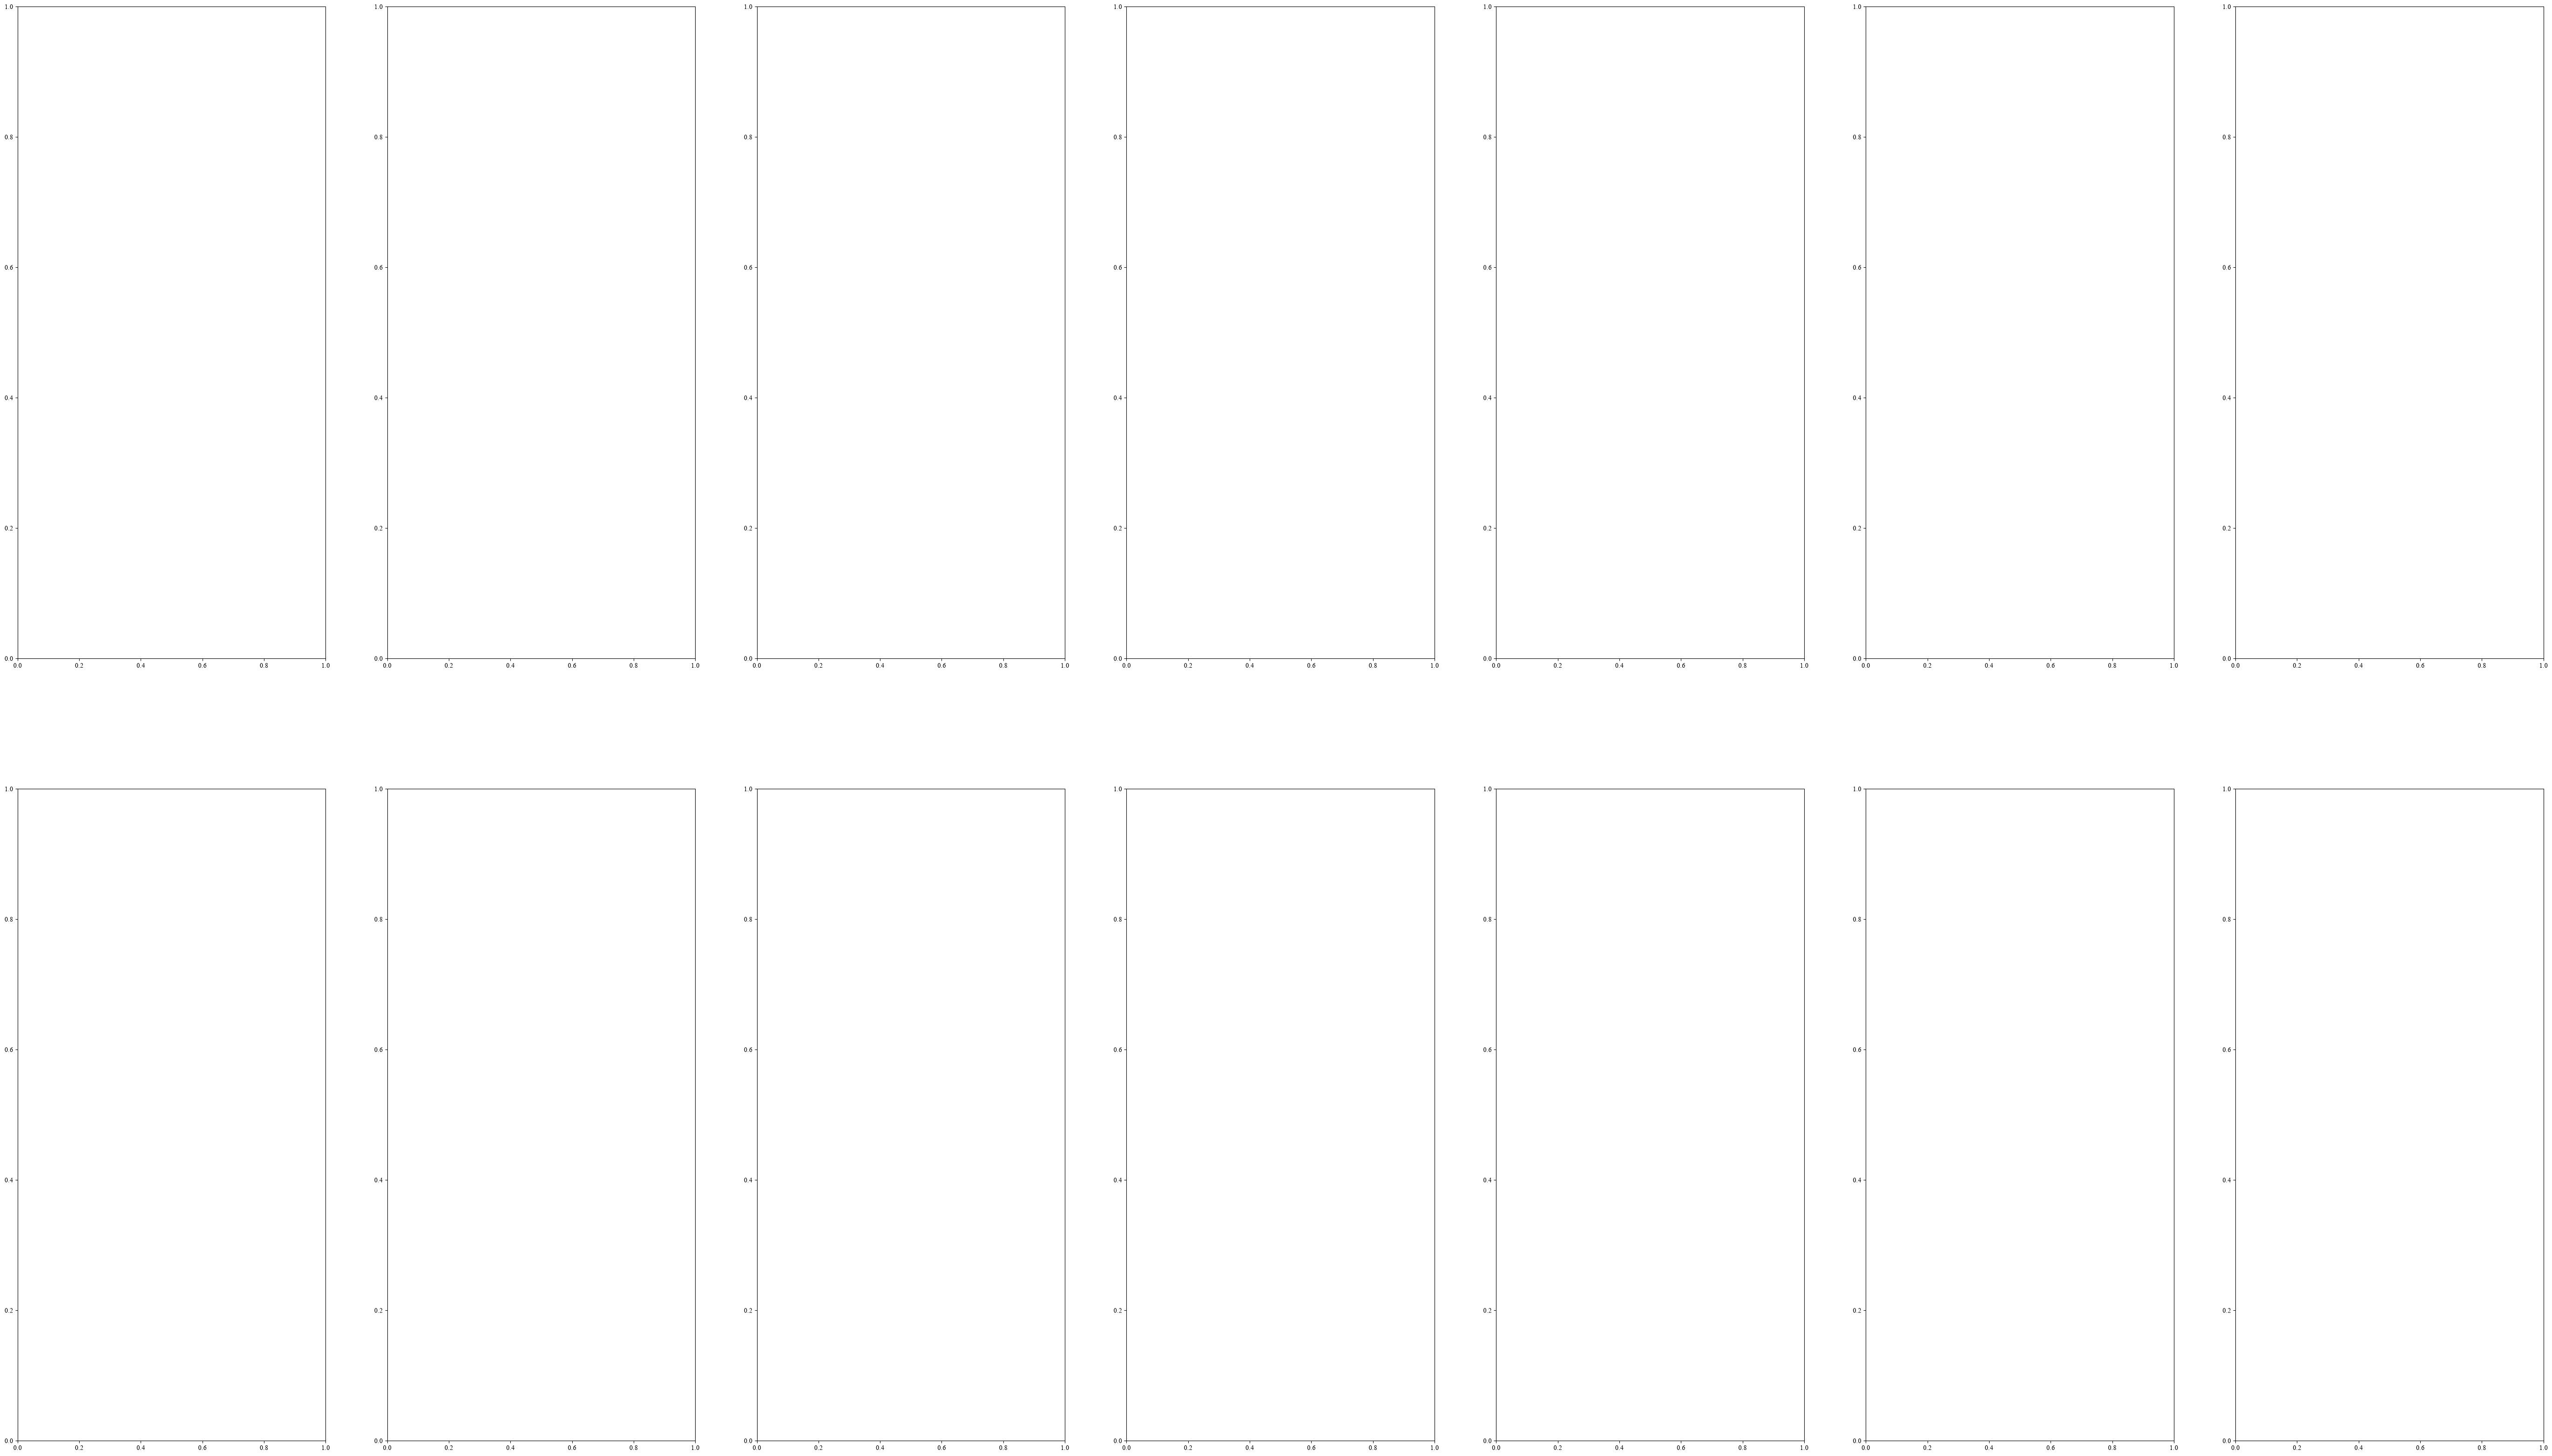

In [12]:
#plot parameters
plt_xmin = 1e-4
plt_xmax = 10
plt_ymin = 1e-40
plt_ymax = 1e-15

fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(70,40))
i = 0
for file in Path(constraint_grid_dir).iterdir():
    constraint_grid = np.loadtxt(file)
    find_non_zero = np.sum(constraint_grid,axis=0)
    constraint_start = np.min(np.where(find_non_zero != 0))
    upper_limit = np.zeros((n_m - constraint_start, 2))
    lower_limit = np.zeros((n_m - constraint_start, 2))
    for col in range(constraint_start, n_m):
        indices = np.where(constraint_grid[:, col] == 1)[0]
        upper_index = n_cs -1 - np.min(indices)
        lower_index = n_cs -1 - np.max(indices)
        index_temp = col - constraint_start
        upper_limit[index_temp, 0] = m_grid[col]
        lower_limit[index_temp, 0] = m_grid[col]
        upper_limit[index_temp, 1] = center_line[col] * cs_grid[upper_index]
        lower_limit[index_temp, 1] = center_line[col] * cs_grid[lower_index]
    row = i // 7  # 当前图的行索引
    col = i % 7   # 当前图的列索引
    axes[row, col].loglog(m_grid, center_line, color = '#9D4224', linestyle='--', linewidth=2.5)
    axes[row, col].fill_between(BBN_Neff[:,0],BBN_Neff[:,1], plt_ymax, color='#B2C2EC', alpha=0.5)
    axes[row, col].loglog(BBN_Neff[:,0],BBN_Neff[:,1], color='#819BE0', alpha=1)
    axes[row, col].fill_between(CMB_Neff[:,0],CMB_Neff[:,1], plt_ymax, color='#C7D798', alpha=0.5)
    axes[row, col].fill_between(SLAC[:,0],SLAC[:,1], plt_ymax, color='#B78EB5', alpha=0.6)
    axes[row, col].fill_between(XQC[:,0], XQC[:,1], plt_ymax, color='#FBCF89', alpha=0.6)
    #axes[row, col].fill_between(terrestrial_limits[:,0], terrestrial_limits[:,1], plt_ymax, color='#AEC0DA', alpha=0.6)
    axes[row, col].fill_between(DD_x_points, DD_upper_interp(DD_x_points), DD_lower_100_interp(DD_x_points), color = '#EC693E', alpha=0.8)
    axes[row, col].loglog(CMB_Neff_2[:,0],CMB_Neff_2[:,1], color='#C7D798', alpha=1)
    axes[row, col].loglog(BBN_Neff_2[:,0],BBN_Neff_2[:,1], color='#819BE0', alpha=0.6)
    axes[row, col].loglog(CMB[:,0],CMB[:,1], color='#7E93A6', alpha=1)
    axes[row, col].fill_between(lower_limit[:,0], lower_limit[:,1], upper_limit[:,1])
    axes[row, col].fill_between(RRS_x_points, RRS_upper_interp(RRS_x_points), RRS_lower_interp(RRS_x_points), color = '#C3BBD9', alpha=0.8)
    axes[row, col].set_title(file.stem[:-16])
    i += 1
plt.tight_layout()
plt.show()